In [1]:
!pip install -q kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import os

# Download TextOCR dataset
print("Downloading TextOCR dataset...")
textocr_path = kagglehub.dataset_download("robikscube/textocr-text-extraction-from-images-dataset")
print("TextOCR Path:", textocr_path)

# List files to be sure of the names
print("\nFiles in dataset:", os.listdir(textocr_path))

# Try to read and display annot.csv
annot_csv_path = os.path.join(textocr_path, "annot.csv")
if os.path.exists(annot_csv_path):
    print("\n--- annot.csv ---")
    annot_df = pd.read_csv(annot_csv_path, nrows=5)
    display(annot_df)
else:
    print(f"{annot_csv_path} not found.")

# Try to read and display image.csv (or similarly named file)
for file in os.listdir(textocr_path):
    if 'img' in file.lower() and file.endswith('.csv'):
        img_csv_path = os.path.join(textocr_path, file)
        print(f"\n--- {file} ---")
        img_df = pd.read_csv(img_csv_path, nrows=5)
        display(img_df)
        break


100%|██████████| 6.73G/6.73G [07:55<00:00, 15.2MB/s]

Extracting files...


TextOCR Path: /root/.cache/kagglehub/datasets/robikscube/textocr-text-extraction-from-images-dataset/versions/2

Files in dataset: ['img.csv', 'annot.csv', 'annot.parquet', 'TextOCR_0.1_train.json', 'img.parquet', 'train_val_images']

--- annot.csv ---


,Unnamed: 0,id,image_id,bbox,utf8_string,points,area
0,0,a4ea732cd3d5948a_1,a4ea732cd3d5948a,"[525.83, 3.4, 197.64, 33.94]",Performance,"[525.83, 3.4, 723.47, 7.29, 722.76, 36.99, 525...",6707.90
1,1,a4ea732cd3d5948a_2,a4ea732cd3d5948a,"[534.67, 64.68, 91.22, 38.19]",Sport,"[535.73, 64.68, 623.41, 67.51, 625.89, 102.87,...",3483.69
2,2,a4ea732cd3d5948a_3,a4ea732cd3d5948a,"[626.95, 63.62, 96.52, 31.82]",Watch,"[626.95, 63.62, 721.7, 63.62, 723.47, 95.44, 6...",3071.27
3,3,a4ea732cd3d5948a_4,a4ea732cd3d5948a,"[577.4, 141.87, 147.13, 43.1]",...period.,"[580.02, 143.61, 724.53, 141.87, 723.66, 184.9...",6341.30
4,4,a4ea732cd3d5948a_5,a4ea732cd3d5948a,"[391.03, 163.9, 60.82, 38.65]",.,"[395.2, 163.9, 451.85, 191.94, 445.59, 202.55,...",2350.69



--- img.csv ---


,Unnamed: 0,id,width,height,set,file_name
0,0,a4ea732cd3d5948a,840,1024,train,train/a4ea732cd3d5948a.jpg
1,1,4bf43a7b2a898044,1024,683,train,train/4bf43a7b2a898044.jpg
2,2,1b55b309b0f50d02,1024,683,train,train/1b55b309b0f50d02.jpg
3,3,00c359f294f7dcd9,1024,680,train,train/00c359f294f7dcd9.jpg
4,4,04b5a37f762b0f51,768,1024,train,train/04b5a37f762b0f51.jpg


In [2]:
import ast
import re
import random
from sklearn.model_selection import train_test_split

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 2
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


# 1. Load TextOCR DataFrames
print("Loading TextOCR annotations...")
annot_df = pd.read_csv(annot_csv_path)
img_df = pd.read_csv(img_csv_path)

# Merge to get file paths alongside annotations
merged_df = annot_df.merge(img_df, left_on='image_id', right_on='id', suffixes=('_annot', '_img'))

# Drop NaNs or empty strings
merged_df = merged_df.dropna(subset=['utf8_string', 'bbox', 'file_name'])
merged_df = merged_df[merged_df['utf8_string'].str.strip() != '']

textocr_img_dir = os.path.join(textocr_path, "train_val_images", "train_images")

# 2. Sample 2110 unique images, then collect all crops from those images
SEED = 42
random.seed(SEED)
unique_img_names = merged_df['file_name'].apply(lambda x: x.split('/')[-1]).unique()
textocr_img_sample = random.sample(list(unique_img_names), 3010)

# Filter merged_df for these images
textocr_img_df = merged_df[merged_df['file_name'].apply(lambda x: x.split('/')[-1]).isin(textocr_img_sample)]

# Group by image for splitting
img_to_records = {}
for img_name in textocr_img_sample:
    img_records = textocr_img_df[textocr_img_df['file_name'].apply(lambda x: x.split('/')[-1]) == img_name]
    img_to_records[img_name] = img_records

# Split images into train/val/test (2110 train, 300 val, 600 test images)
train_imgs, temp_imgs = train_test_split(textocr_img_sample, train_size=2110, random_state=SEED)
val_imgs, test_imgs = train_test_split(temp_imgs, train_size=300, random_state=SEED)

# Helper to get all crops for a list of images
def get_crops_for_imgs(img_list):
    crops = []

    for img_name in img_list:
        img_records = img_to_records[img_name]

        for _, row in img_records.iterrows():
            text = str(row['utf8_string']).strip()
            if text == '###' or len(text) == 0:
                continue

            text = normalize_crnn_text(text)
            if len(text) < CRNN_MIN_TEXT_LEN:
                continue
            if len(text) > CRNN_MAX_TEXT_LEN:
                continue

            try:
                bbox = ast.literal_eval(row['bbox'])
                x, y, w, h = bbox
                polygon = [(x, y), (x+w, y), (x+w, y+h), (x, y+h)]

                img_file_path = os.path.join(textocr_img_dir, img_name)
                crops.append((img_file_path, text, polygon))
            except Exception:
                continue

    return crops


textocr_train = get_crops_for_imgs(train_imgs)
textocr_val = get_crops_for_imgs(val_imgs)
textocr_test = get_crops_for_imgs(test_imgs)

print("\n--- TextOCR Dataset Splits (by images) ---")
print(f"Train: {len(textocr_train)} crops from {len(train_imgs)} images")
print(f"Val:   {len(textocr_val)} crops from {len(val_imgs)} images")
print(f"Test:  {len(textocr_test)} crops from {len(test_imgs)} images")

# Optionally, save the split for reproducibility
import pickle
with open('textocr_split.pkl', 'wb') as f:
    pickle.dump({'train': textocr_train, 'val': textocr_val, 'test': textocr_test}, f)


Loading TextOCR annotations...

--- TextOCR Dataset Splits (by images) ---
Train: 57584 crops from 2110 images
Val:   7487 crops from 300 images
Test:  18527 crops from 600 images


In [3]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless matplotlib Pillow scipy scikit-learn editdistance
!pip install -q gdown

import torch
print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
GPU available: True
GPU: NVIDIA A100-SXM4-80GB


In [4]:
import os
import gdown
import shutil
import zipfile
import kagglehub

# Download dataset
path = kagglehub.dataset_download("ipythonx/totaltextstr")

print("Path to dataset files:", path)

# Target directory
TARGET_DIR = 'data/totaltext'

# Find actual dataset folder (sometimes nested)
def find_total_text_dir(root):
    for dirpath, dirnames, filenames in os.walk(root):
        if 'Train' in dirnames and 'Test' in dirnames and 'Annotation' in dirnames:
            return dirpath
    return None

SOURCE_DIR = find_total_text_dir(path)

if SOURCE_DIR is None:
    raise Exception("Could not find dataset structure!")

print("Using dataset at:", SOURCE_DIR)

# Create clean structure
train_dst = os.path.join(TARGET_DIR, 'images/train')
test_dst = os.path.join(TARGET_DIR, 'images/test')
annot_dst = os.path.join(TARGET_DIR, 'annotations')

os.makedirs(train_dst, exist_ok=True)
os.makedirs(test_dst, exist_ok=True)

# Copy data
shutil.copytree(os.path.join(SOURCE_DIR, 'Train'), train_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Test'), test_dst, dirs_exist_ok=True)
shutil.copytree(os.path.join(SOURCE_DIR, 'Annotation'), annot_dst, dirs_exist_ok=True)

print("Dataset ready at:", TARGET_DIR)

100%|██████████| 494M/494M [00:35<00:00, 14.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ipythonx/totaltextstr/versions/1
Using dataset at: /root/.cache/kagglehub/datasets/ipythonx/totaltextstr/versions/1/Total-Text
Dataset ready at: data/totaltext


In [5]:

# Verify structure
!find data/totaltext -maxdepth 3 -type d | head -20

data/totaltext
data/totaltext/annotations
data/totaltext/annotations/groundtruth_textregion
data/totaltext/annotations/groundtruth_textregion/Train
data/totaltext/annotations/groundtruth_textregion/Test
data/totaltext/annotations/groundtruth_polygonal_annotation
data/totaltext/annotations/groundtruth_polygonal_annotation/Train
data/totaltext/annotations/groundtruth_polygonal_annotation/Test
data/totaltext/annotations/groundtruth_pixel
data/totaltext/annotations/groundtruth_pixel/Train
data/totaltext/annotations/groundtruth_pixel/Test
data/totaltext/images
data/totaltext/images/train
data/totaltext/images/test


In [6]:
import os
import re
import glob
import json
import random
import numpy as np
import cv2
import editdistance
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

CRNN_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'
CRNN_CHARSET_SET = set(CRNN_CHARSET)
CRNN_MIN_TEXT_LEN = 2
CRNN_MAX_TEXT_LEN = 25


def normalize_crnn_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in CRNN_CHARSET_SET)
    return text


def normalize_crnn_records(records, min_length=CRNN_MIN_TEXT_LEN, max_length=CRNN_MAX_TEXT_LEN):
    normalized_records = []
    skipped = 0

    for img_path, text, polygon in records:
        normalized = normalize_crnn_text(text)
        if len(normalized) < min_length or len(normalized) > max_length:
            skipped += 1
            continue
        normalized_records.append((img_path, normalized, polygon))

    return normalized_records, skipped


# ─── CONFIG ────────────────────────────────────────────────────────────────
class Config:
    # Paths
    TRAIN_IMG_DIR  = 'data/totaltext/images/train'
    TEST_IMG_DIR   = 'data/totaltext/images/test'
    TRAIN_GT_DIR   = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Train'
    TEST_GT_DIR    = 'data/totaltext/annotations/groundtruth_polygonal_annotation/Test'

    # Image
    IMG_HEIGHT     = 32      # Fixed CRNN input height
    IMG_WIDTH      = 256     # Maximum width after keep-ratio resize and right padding
    IMG_CHANNELS   = 1       # Grayscale

    # Model
    CNN_OUT_CHANNELS   = 512
    RNN_HIDDEN_SIZE    = 256
    RNN_NUM_LAYERS     = 2
    RNN_DROPOUT        = 0.3
    LEAKY_RELU         = False
    FREEZE_CNN_EPOCHS  = 1

    # Training
    BATCH_SIZE     = 64
    NUM_EPOCHS     = 20
    LR             = 2e-4
    LR_STEP        = 6
    LR_GAMMA       = 0.7
    WEIGHT_DECAY   = 5e-5
    GRAD_CLIP      = 5.0
    NUM_WORKERS    = 4
    SEED           = 42

    # Charset
    CHARSET        = CRNN_CHARSET
    MIN_TEXT_LEN   = CRNN_MIN_TEXT_LEN
    MAX_TEXT_LEN   = CRNN_MAX_TEXT_LEN
    BLANK_IDX      = 0       # CTC blank token index

    DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
    SAVE_PATH      = 'crnn_totaltext_best.pth'
    # PRETRAINED_PATH = 'crnn_pretrained_synthtext.pth'

cfg = Config()

# Reproducibility
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

print(f'Device: {cfg.DEVICE}')
print(f'Charset size: {len(cfg.CHARSET)}')
print(f'Charset: {cfg.CHARSET}')

Device: cuda
Charset size: 36
Charset: 0123456789abcdefghijklmnopqrstuvwxyz


In [7]:
class LabelEncoder:
    """Maps characters <-> integer indices. Index 0 is reserved for CTC blank."""

    def __init__(self, charset: str):
        self.chars = ['[BLANK]'] + list(charset)
        self.char2idx = {c: i for i, c in enumerate(self.chars)}
        self.idx2char = {i: c for i, c in enumerate(self.chars)}
        self.num_classes = len(self.chars)

    def encode(self, text: str):
        """str -> LongTensor of indices. Unknown chars are rejected to catch normalization drift."""
        unknown_chars = sorted({ch for ch in text if ch not in self.char2idx})
        if unknown_chars:
            raise ValueError(
                f'Found characters outside the configured charset: {unknown_chars}. '
                'Normalize the dataset records before encoding.'
            )
        return torch.LongTensor([self.char2idx[ch] for ch in text])

    def decode(self, indices, remove_duplicates=True, remove_blank=True):
        """LongTensor/list -> str. Supports both plain label decode and CTC greedy decode."""
        invalid_indices = sorted({int(idx) for idx in indices if int(idx) not in self.idx2char})
        if invalid_indices:
            raise ValueError(f'Found indices outside the decoder vocabulary: {invalid_indices}')

        result = []
        prev = None
        for idx in indices:
            idx = int(idx)
            if remove_duplicates and idx == prev:
                prev = idx
                continue
            prev = idx
            if remove_blank and idx == 0:
                continue
            char = self.idx2char[idx]
            if char != '[BLANK]':
                result.append(char)
        return ''.join(result)


label_encoder = LabelEncoder(cfg.CHARSET)
print(f'Num classes (incl. blank): {label_encoder.num_classes}')

# Quick test
sample = 'hello123'
enc = label_encoder.encode(sample)
dec = label_encoder.decode(enc)
print(f'Encode->Decode test: "{sample}" -> {enc.tolist()} -> "{dec}"')

Num classes (incl. blank): 37
Encode->Decode test: "hello123" -> [18, 15, 22, 22, 25, 2, 3, 4] -> "helo123"


In [8]:
def parse_totaltext_annotations(img_dir, gt_dir):
    records = []

    img_paths = glob.glob(os.path.join(img_dir, '*.jpg'))
    print(f'Found {len(img_paths)} images in {img_dir}')

    for img_path in img_paths:
        img_name = os.path.basename(img_path)
        gt_name = f'gt_{os.path.splitext(img_name)[0]}.txt'
        gt_path = os.path.join(gt_dir, gt_name)

        if not os.path.exists(gt_path):
            continue

        with open(gt_path, 'r', encoding='utf-8') as f:
            content = f.read()

        matches = re.findall(
            r"x:\s*\[(.*?)\],\s*y:\s*\[(.*?)\],\s*transcription:\s*'([^']*)'",
            content
        )

        for x_str, y_str, text in matches:
            if text.strip() == '#':
                continue

            normalized_text = normalize_crnn_text(text)
            if len(normalized_text) < cfg.MIN_TEXT_LEN or len(normalized_text) > cfg.MAX_TEXT_LEN:
                continue

            try:
                xs = list(map(int, re.split(r'[,\s]+', x_str.strip())))
                ys = list(map(int, re.split(r'[,\s]+', y_str.strip())))

                if len(xs) != len(ys) or len(xs) < 3:
                    continue

                polygon = list(zip(xs, ys))
                records.append((img_path, normalized_text, polygon))
            except Exception:
                continue

    print(f'Total word crops: {len(records)}')
    return records


def crop_polygon_region(image: np.ndarray, polygon: list, target_h: int = 32):
    """
    Crops the bounding-box of a polygon from an image and resizes to target_h.
    Returns a grayscale image of shape (target_h, W).
    """
    pts = np.array(polygon, dtype=np.int32)
    x, y, w, h = cv2.boundingRect(pts)
    x, y = max(0, x), max(0, y)
    x2  = min(image.shape[1], x + w)
    y2  = min(image.shape[0], y + h)
    if x2 <= x or y2 <= y:
        return None
    crop = image[y:y2, x:x2]
    if crop.size == 0:
        return None
    if len(crop.shape) == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    aspect = w / max(h, 1)
    new_w  = max(1, int(target_h * aspect))
    crop   = cv2.resize(crop, (new_w, target_h))
    return crop


def parse_totaltext_gt(gt_file):
    anns = []

    with open(gt_file, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    for line in lines:
        try:
            x_match = re.search(r"x:\s*\[\[([^\]]+)\]\]", line)
            y_match = re.search(r"y:\s*\[\[([^\]]+)\]\]", line)
            t_match = re.search(r"transcriptions:\s*\[u'([^']*)'\]", line)

            if not x_match or not y_match or not t_match:
                continue

            text = normalize_crnn_text(t_match.group(1))
            if len(text) < cfg.MIN_TEXT_LEN or len(text) > cfg.MAX_TEXT_LEN:
                continue

            xs = list(map(int, x_match.group(1).split()))
            ys = list(map(int, y_match.group(1).split()))

            if len(xs) != len(ys) or len(xs) < 3:
                continue

            polygon = list(zip(xs, ys))
            anns.append({
                'text': text,
                'polygon': polygon
            })
        except Exception:
            continue

    return anns


def build_dataset_records(img_dir: str, gt_dir: str):
    """Walk through Total Text split and return list of (img_path, text, polygon)."""
    records = []
    img_paths = glob.glob(os.path.join(img_dir, '*.jpg')) + \
                glob.glob(os.path.join(img_dir, '*.png'))
    print(f'Found {len(img_paths)} images in {img_dir}')
    for img_path in img_paths:
        stem = Path(img_path).stem
        gt_file = os.path.join(gt_dir, f'poly_gt_{stem}.txt')
        if not os.path.exists(gt_file):
            continue
        anns = parse_totaltext_gt(gt_file)
        for ann in anns:
            records.append((img_path, ann['text'], ann['polygon']))
    print(f'Total word crops: {len(records)}')
    return records


train_records = build_dataset_records(cfg.TRAIN_IMG_DIR, cfg.TRAIN_GT_DIR)
test_records  = build_dataset_records(cfg.TEST_IMG_DIR,  cfg.TEST_GT_DIR)
print(f'Train: {len(train_records)}, Test: {len(test_records)}')

Found 1254 images in data/totaltext/images/train
Total word crops: 8991
Found 300 images in data/totaltext/images/test
Total word crops: 2132
Train: 8991, Test: 2132


In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm


class TotalTextDataset(Dataset):
    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records = records
        self.label_encoder = label_encoder
        self.cfg = cfg
        self.augment = augment
        self.max_width = cfg.IMG_WIDTH
        self.height = cfg.IMG_HEIGHT

        aug_list = []
        if augment:
            aug_list += [
                transforms.RandomAffine(degrees=3, shear=5),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            ]
        self.pil_transform = transforms.Compose(aug_list) if aug_list else None
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.records)

    def _resize_keep_ratio_pad(self, crop):
        h, w = crop.shape
        if h != self.height:
            new_w = max(1, int(round(w * (self.height / max(h, 1)))))
            crop = cv2.resize(crop, (new_w, self.height), interpolation=cv2.INTER_CUBIC)
            h, w = crop.shape

        if w > self.max_width:
            crop = cv2.resize(crop, (self.max_width, self.height), interpolation=cv2.INTER_CUBIC)
            w = self.max_width

        if w < self.max_width:
            pad_w = self.max_width - w
            crop = cv2.copyMakeBorder(crop, 0, 0, 0, pad_w, cv2.BORDER_REPLICATE)

        return crop[:, :self.max_width]

    def __getitem__(self, idx):
        img_path, text, _ = self.records[idx]

        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            img_t = torch.zeros(1, self.height, self.max_width)
            label = self.label_encoder.encode('a')
            return img_t, label, len(label)

        if self.augment:
          crop = apply_degradation_pipeline(crop, MILD_SEVERITY, ALL_DEGRADATIONS,
                                          num_degradations=2, adaptive=True)

        crop = self._resize_keep_ratio_pad(crop)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)


def collate_fn(batch):
    images, labels, lengths = zip(*batch)
    images = torch.stack(images, 0)
    lengths = torch.LongTensor(lengths)
    targets = torch.cat(labels)
    return images, targets, lengths


import random
from sklearn.model_selection import train_test_split

# --- Merge TotalText and TextOCR ---
print("Merging datasets...")
# Use the official Total-Text train split for training.
# Split the official Total-Text test images at the image level into validation and test.
# Reuse the preselected TextOCR image-level splits.

tt_train_records = train_records


def filter_records_by_img_paths(records, img_paths):
    img_path_set = set(img_paths)
    return [record for record in records if record[0] in img_path_set]


def prepare_crnn_records(records, name):
    normalized_records, skipped = normalize_crnn_records(
        records,
        min_length=cfg.MIN_TEXT_LEN,
        max_length=cfg.MAX_TEXT_LEN,
    )
    print(f'{name}: kept {len(normalized_records)} / {len(records)} records after CRNN normalization (skipped {skipped})')
    return normalized_records


random.seed(cfg.SEED)
tt_test_img_paths = sorted({img_path for img_path, _, _ in test_records})
if len(tt_test_img_paths) < 2:
    raise ValueError('Need at least two Total-Text test images to build validation and test splits.')

tt_val_img_paths, tt_test_img_paths = train_test_split(
    tt_test_img_paths,
    test_size=0.5,
    random_state=cfg.SEED,
)

print(f'Total-Text image split -> train: {len({img_path for img_path, _, _ in tt_train_records})}, val: {len(tt_val_img_paths)}, test: {len(tt_test_img_paths)}')

tt_val_records = filter_records_by_img_paths(test_records, tt_val_img_paths)
tt_test_records = filter_records_by_img_paths(test_records, tt_test_img_paths)

import pickle
with open('textocr_split.pkl', 'rb') as f:
    textocr_split = pickle.load(f)
textocr_train = textocr_split['train']
textocr_val = textocr_split['val']
textocr_test = textocr_split['test']

tt_train_records = prepare_crnn_records(tt_train_records, 'Total-Text train')
tt_val_records = prepare_crnn_records(tt_val_records, 'Total-Text val')
tt_test_records = prepare_crnn_records(tt_test_records, 'Total-Text test')
textocr_train = prepare_crnn_records(textocr_train, 'TextOCR train')
textocr_val = prepare_crnn_records(textocr_val, 'TextOCR val')
textocr_test = prepare_crnn_records(textocr_test, 'TextOCR test')

final_train_records = tt_train_records + textocr_train
final_val_records = tt_val_records + textocr_val
final_test_records = tt_test_records + textocr_test

random.shuffle(final_train_records)
FAST_MODE = False
FAST_FRAC = 0.25

if FAST_MODE:
    random.seed(cfg.SEED)
    final_train_records = random.sample(final_train_records, int(len(final_train_records) * FAST_FRAC))
    final_val_records = random.sample(final_val_records, int(len(final_val_records) * FAST_FRAC))
    final_test_records = random.sample(final_test_records, int(len(final_test_records) * FAST_FRAC))
    print(f"[FAST MODE] Train: {len(final_train_records)}, Val: {len(final_val_records)}, Test: {len(final_test_records)}")


def pre_crop_dataset(records, output_dir, target_h=32):
    """
    Crop all word regions once and save as individual images.
    Returns new records pointing to the pre-cropped files.
    """
    os.makedirs(output_dir, exist_ok=True)
    new_records = []

    for i, (img_path, text, polygon) in enumerate(tqdm(records, desc="Pre-cropping")):
        image = cv2.imread(img_path)
        if image is None:
            continue

        crop = crop_polygon_region(image, polygon, target_h=target_h)
        if crop is None:
            continue
        if crop.shape[1] < 32:
            continue

        crop_path = os.path.join(output_dir, f"{i:06d}.png")
        cv2.imwrite(crop_path, crop)
        new_records.append((crop_path, text, None))

    print(f"Saved {len(new_records)} crops to {output_dir}")
    return new_records


# Run once -- takes a few minutes but saves hours later
final_train_records = pre_crop_dataset(final_train_records, "data/crops/train", cfg.IMG_HEIGHT)
final_val_records = pre_crop_dataset(final_val_records, "data/crops/val", cfg.IMG_HEIGHT)
final_test_records = pre_crop_dataset(final_test_records, "data/crops/test", cfg.IMG_HEIGHT)
print(f"Final Train: {len(final_train_records)} crops")
print(f"Final Val:   {len(final_val_records)} crops")
print(f"Final Test:  {len(final_test_records)} crops")



Merging datasets...
Total-Text image split -> train: 1253, val: 149, test: 150
Total-Text train: kept 8991 / 8991 records after CRNN normalization (skipped 0)
Total-Text val: kept 1059 / 1059 records after CRNN normalization (skipped 0)
Total-Text test: kept 1073 / 1073 records after CRNN normalization (skipped 0)
TextOCR train: kept 57584 / 57584 records after CRNN normalization (skipped 0)
TextOCR val: kept 7487 / 7487 records after CRNN normalization (skipped 0)
TextOCR test: kept 18527 / 18527 records after CRNN normalization (skipped 0)


Pre-cropping: 100%|██████████| 66575/66575 [07:44<00:00, 143.39it/s]


Saved 57886 crops to data/crops/train


Pre-cropping: 100%|██████████| 8546/8546 [00:58<00:00, 144.99it/s]


Saved 7152 crops to data/crops/val


Pre-cropping: 100%|██████████| 19600/19600 [02:10<00:00, 150.24it/s]

Saved 17212 crops to data/crops/test
Final Train: 57886 crops
Final Val:   7152 crops
Final Test:  17212 crops


In [10]:
"""
Size-Adaptive Noise Pipeline for Scene Text Recognition
========================================================
Applies degradations scaled by crop width so small crops don't get destroyed.
Supports both on-the-fly training augmentation and fixed test set generation.

Usage:
  1. Run the visualization cell first to inspect samples
  2. Adjust severity levels if needed
  3. Generate degraded test sets to disk
  4. Plug into dataset __getitem__ for training augmentation
"""

import os
import cv2
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Severity Configs
# ---------------------------------------------------------------------------

MILD_SEVERITY = {
    'jpeg_quality':       (40, 60),    # quality range (lower = worse)
    'gaussian_noise_sigma': (10, 25),  # pixel noise std dev
    'downsample_factor':  (1.5, 2.0),  # resize down then back up
    'gaussian_blur_ksize': (3, 5),     # blur kernel size (odd numbers)
    'motion_blur_ksize':  (3, 5),      # directional blur kernel
}

HEAVY_SEVERITY = {
    'jpeg_quality':       (15, 30),
    'gaussian_noise_sigma': (30, 50),
    'downsample_factor':  (2.5, 4.0),
    'gaussian_blur_ksize': (5, 9),
    'motion_blur_ksize':  (5, 9),
}


# ---------------------------------------------------------------------------
# Size-Adaptive Scaling
# ---------------------------------------------------------------------------

def _width_scale(crop_width):
    """
    Returns a 0-1 scale factor based on crop width.
    Small crops get gentler degradation to stay readable.
    """
    if crop_width < 30:
        return 0.0   # too small, skip spatial degradations
    elif crop_width < 50:
        return 0.3
    elif crop_width < 100:
        return 0.6
    elif crop_width < 150:
        return 0.8
    else:
        return 1.0


def _scale_range(base_range, scale):
    """Scale a (low, high) severity range by the width factor."""
    low, high = base_range
    # Shrink the range toward the mild end
    scaled_high = low + (high - low) * scale
    scaled_low = low + (scaled_high - low) * 0.3  # keep some minimum
    return (max(low, scaled_low), max(low + 1, scaled_high))


# ---------------------------------------------------------------------------
# Individual Degradation Functions
# ---------------------------------------------------------------------------

def apply_jpeg_compression(crop, quality_range):
    """Compress and decompress via JPEG buffer."""
    q = random.randint(int(quality_range[0]), int(quality_range[1]))
    encode_params = [cv2.IMWRITE_JPEG_QUALITY, q]
    _, buf = cv2.imencode('.jpg', crop, encode_params)
    return cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)


def apply_gaussian_noise(crop, sigma_range):
    """Add pixel-level gaussian noise."""
    sigma = random.uniform(sigma_range[0], sigma_range[1])
    noise = np.random.normal(0, sigma, crop.shape).astype(np.float32)
    noisy = np.clip(crop.astype(np.float32) + noise, 0, 255)
    return noisy.astype(np.uint8)


def apply_downsample_upsample(crop, factor_range):
    """Downsample then upsample to simulate low-resolution capture."""
    factor = random.uniform(factor_range[0], factor_range[1])
    h, w = crop.shape
    small_h = max(4, int(h / factor))
    small_w = max(4, int(w / factor))
    small = cv2.resize(crop, (small_w, small_h), interpolation=cv2.INTER_LINEAR)
    return cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)


def apply_gaussian_blur(crop, ksize_range):
    """Apply gaussian blur with random kernel size."""
    k = random.randrange(int(ksize_range[0]), int(ksize_range[1]) + 1, 2)  # odd only
    if k % 2 == 0:
        k += 1
    k = max(3, k)
    return cv2.GaussianBlur(crop, (k, k), 0)


def apply_motion_blur(crop, ksize_range):
    """Apply directional motion blur."""
    k = random.randrange(int(ksize_range[0]), int(ksize_range[1]) + 1, 2)
    if k < 3:
        k = 3
    # Random direction: horizontal, vertical, or diagonal
    direction = random.choice(['horizontal', 'vertical', 'diagonal'])
    kernel = np.zeros((k, k), dtype=np.float32)
    if direction == 'horizontal':
        kernel[k // 2, :] = 1.0
    elif direction == 'vertical':
        kernel[:, k // 2] = 1.0
    else:
        np.fill_diagonal(kernel, 1.0)
    kernel /= kernel.sum()
    return cv2.filter2D(crop, -1, kernel)


# ---------------------------------------------------------------------------
# Degradation Pipeline
# ---------------------------------------------------------------------------

# Map of all available degradations
DEGRADATION_FUNCTIONS = {
    'jpeg':       lambda crop, sev: apply_jpeg_compression(crop, sev['jpeg_quality']),
    'noise':      lambda crop, sev: apply_gaussian_noise(crop, sev['gaussian_noise_sigma']),
    'downsample': lambda crop, sev: apply_downsample_upsample(crop, sev['downsample_factor']),
    'blur':       lambda crop, sev: apply_gaussian_blur(crop, sev['gaussian_blur_ksize']),
    'motion':     lambda crop, sev: apply_motion_blur(crop, sev['motion_blur_ksize']),
}

# Degradation groups for targeted test sets
LOWRES_DEGRADATIONS = ['jpeg', 'noise', 'downsample']   # for TPGSR evaluation
BLUR_DEGRADATIONS = ['blur', 'motion']                    # for SVTR evaluation
ALL_DEGRADATIONS = list(DEGRADATION_FUNCTIONS.keys())


def apply_degradation_pipeline(crop, severity_config, degradation_list=None,
                               num_degradations=None, adaptive=True):
    """
    Apply random degradations to a grayscale crop.

    Args:
        crop:              grayscale numpy array (H, W)
        severity_config:   MILD_SEVERITY or HEAVY_SEVERITY dict
        degradation_list:  which degradations to sample from (default: all)
        num_degradations:  how many to apply (default: random 1-2)
        adaptive:          scale severity by crop width

    Returns:
        degraded crop (same shape as input)
    """
    if crop is None or crop.size == 0:
        return crop

    h, w = crop.shape
    if degradation_list is None:
        degradation_list = ALL_DEGRADATIONS

    if num_degradations is None:
        num_degradations = random.randint(1, min(2, len(degradation_list)))

    # Scale severity by crop width
    if adaptive:
        scale = _width_scale(w)
        if scale == 0.0:
            # Crop too small for spatial degradation, only allow JPEG
            degradation_list = ['jpeg'] if 'jpeg' in degradation_list else []
            scale = 0.5
        scaled_config = {}
        for key, val in severity_config.items():
            scaled_config[key] = _scale_range(val, scale)
    else:
        scaled_config = severity_config

    # Pick random subset of degradations
    chosen = random.sample(degradation_list, min(num_degradations, len(degradation_list)))

    result = crop.copy()
    for deg_name in chosen:
        if deg_name in DEGRADATION_FUNCTIONS:
            result = DEGRADATION_FUNCTIONS[deg_name](result, scaled_config)

    return result


def apply_fixed_degradation(crop, severity_config, degradation_list, adaptive=True):
    """
    Apply ALL specified degradations (for reproducible test sets).
    Unlike the random pipeline, this applies every degradation in the list.
    """
    if crop is None or crop.size == 0:
        return crop

    h, w = crop.shape
    if adaptive:
        scale = _width_scale(w)
        if scale == 0.0:
            degradation_list = [d for d in degradation_list if d == 'jpeg']
            scale = 0.5
        scaled_config = {}
        for key, val in severity_config.items():
            scaled_config[key] = _scale_range(val, scale)
    else:
        scaled_config = severity_config

    result = crop.copy()
    for deg_name in degradation_list:
        if deg_name in DEGRADATION_FUNCTIONS:
            result = DEGRADATION_FUNCTIONS[deg_name](result, scaled_config)
    return result




In [11]:
# ---------------------------------------------------------------------------
# Visualization -- RUN THIS FIRST to check if degradations are readable
# ---------------------------------------------------------------------------

def visualize_degradations(records, n=8, seed=42):
    """
    Show n random crops with clean vs mild vs heavy degradation side by side.
    Includes crop width in the title so you can verify size-adaptive scaling.
    """
    random.seed(seed)
    np.random.seed(seed)
    indices = random.sample(range(len(records)), min(n, len(records)))

    fig, axes = plt.subplots(n, 3, figsize=(14, 3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    axes[0, 0].set_title('Clean', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Mild Degradation', fontsize=12, fontweight='bold')
    axes[0, 2].set_title('Heavy Degradation', fontsize=12, fontweight='bold')

    for row, idx in enumerate(indices):
        img_path, text, _ = records[idx]
        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            continue

        h, w = crop.shape

        # Seed each row the same so mild/heavy use same random choices
        random.seed(seed + idx)
        np.random.seed(seed + idx)
        mild = apply_degradation_pipeline(crop, MILD_SEVERITY, ALL_DEGRADATIONS,
                                          num_degradations=2, adaptive=True)

        random.seed(seed + idx)
        np.random.seed(seed + idx)
        heavy = apply_degradation_pipeline(crop, HEAVY_SEVERITY, ALL_DEGRADATIONS,
                                           num_degradations=2, adaptive=True)

        for col, img in enumerate([crop, mild, heavy]):
            axes[row, col].imshow(img, cmap='gray', aspect='auto')
            axes[row, col].set_ylabel(f'"{text}" (w={w})', fontsize=9)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])

    plt.tight_layout()
    plt.show()


def visualize_specific_degradations(records, n=6, seed=42):
    """
    Show each degradation type individually on the same crop.
    Helps identify which degradation is too aggressive.
    """
    random.seed(seed)
    np.random.seed(seed)
    indices = random.sample(range(len(records)), min(n, len(records)))

    deg_names = ALL_DEGRADATIONS
    ncols = len(deg_names) + 1  # clean + each degradation

    fig, axes = plt.subplots(n, ncols, figsize=(3 * ncols, 3 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    axes[0, 0].set_title('Clean', fontsize=10, fontweight='bold')
    for j, name in enumerate(deg_names):
        axes[0, j + 1].set_title(f'{name}\n(heavy)', fontsize=10, fontweight='bold')

    for row, idx in enumerate(indices):
        img_path, text, _ = records[idx]
        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            continue

        h, w = crop.shape
        axes[row, 0].imshow(crop, cmap='gray', aspect='auto')
        axes[row, 0].set_ylabel(f'"{text}" (w={w})', fontsize=8)
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        for j, name in enumerate(deg_names):
            random.seed(seed + idx + j)
            np.random.seed(seed + idx + j)
            degraded = apply_fixed_degradation(crop, HEAVY_SEVERITY, [name], adaptive=True)
            axes[row, j + 1].imshow(degraded, cmap='gray', aspect='auto')
            axes[row, j + 1].set_xticks([])
            axes[row, j + 1].set_yticks([])

    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Generate Degraded Test Sets (saved to disk for reproducibility)
# ---------------------------------------------------------------------------

def generate_degraded_test_set(records, output_dir, severity_config,
                                degradation_list, seed=42):
    """
    Apply fixed degradation to all crops and save to disk.

    Args:
        records:           list of (img_path, text, polygon) tuples
        output_dir:        where to save degraded crops
        severity_config:   MILD_SEVERITY or HEAVY_SEVERITY
        degradation_list:  which degradations to apply

    Returns:
        new records list pointing to degraded images
    """
    os.makedirs(output_dir, exist_ok=True)
    new_records = []
    random.seed(seed)
    np.random.seed(seed)

    for i, (img_path, text, polygon) in enumerate(tqdm(records, desc=f"Degrading -> {output_dir}")):
        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            continue

        degraded = apply_fixed_degradation(crop, severity_config, degradation_list,
                                            adaptive=True)

        save_path = os.path.join(output_dir, f"{i:06d}.png")
        cv2.imwrite(save_path, degraded)
        new_records.append((save_path, text, None))

    print(f"Saved {len(new_records)} degraded crops to {output_dir}")
    return new_records


# ---------------------------------------------------------------------------
# Generate All Test Variants
# ---------------------------------------------------------------------------

def generate_all_test_sets(test_records, base_dir="data/degraded_test"):
    """
    Generate the full suite of degraded test sets.

    Creates:
      - mild_lowres/    JPEG + noise + downsample (mild)
      - heavy_lowres/   JPEG + noise + downsample (heavy)
      - mild_blur/      gaussian + motion blur (mild)
      - heavy_blur/     gaussian + motion blur (heavy)

    Returns dict of {name: records_list}
    """
    test_sets = {}

    # Low-res / noisy (for TPGSR evaluation)
    test_sets['mild_lowres'] = generate_degraded_test_set(
        test_records, os.path.join(base_dir, "mild_lowres"),
        MILD_SEVERITY, LOWRES_DEGRADATIONS
    )
    test_sets['heavy_lowres'] = generate_degraded_test_set(
        test_records, os.path.join(base_dir, "heavy_lowres"),
        HEAVY_SEVERITY, LOWRES_DEGRADATIONS
    )

    # Blur (for SVTR evaluation)
    test_sets['mild_blur'] = generate_degraded_test_set(
        test_records, os.path.join(base_dir, "mild_blur"),
        MILD_SEVERITY, BLUR_DEGRADATIONS
    )
    test_sets['heavy_blur'] = generate_degraded_test_set(
        test_records, os.path.join(base_dir, "heavy_blur"),
        HEAVY_SEVERITY, BLUR_DEGRADATIONS
    )

    return test_sets

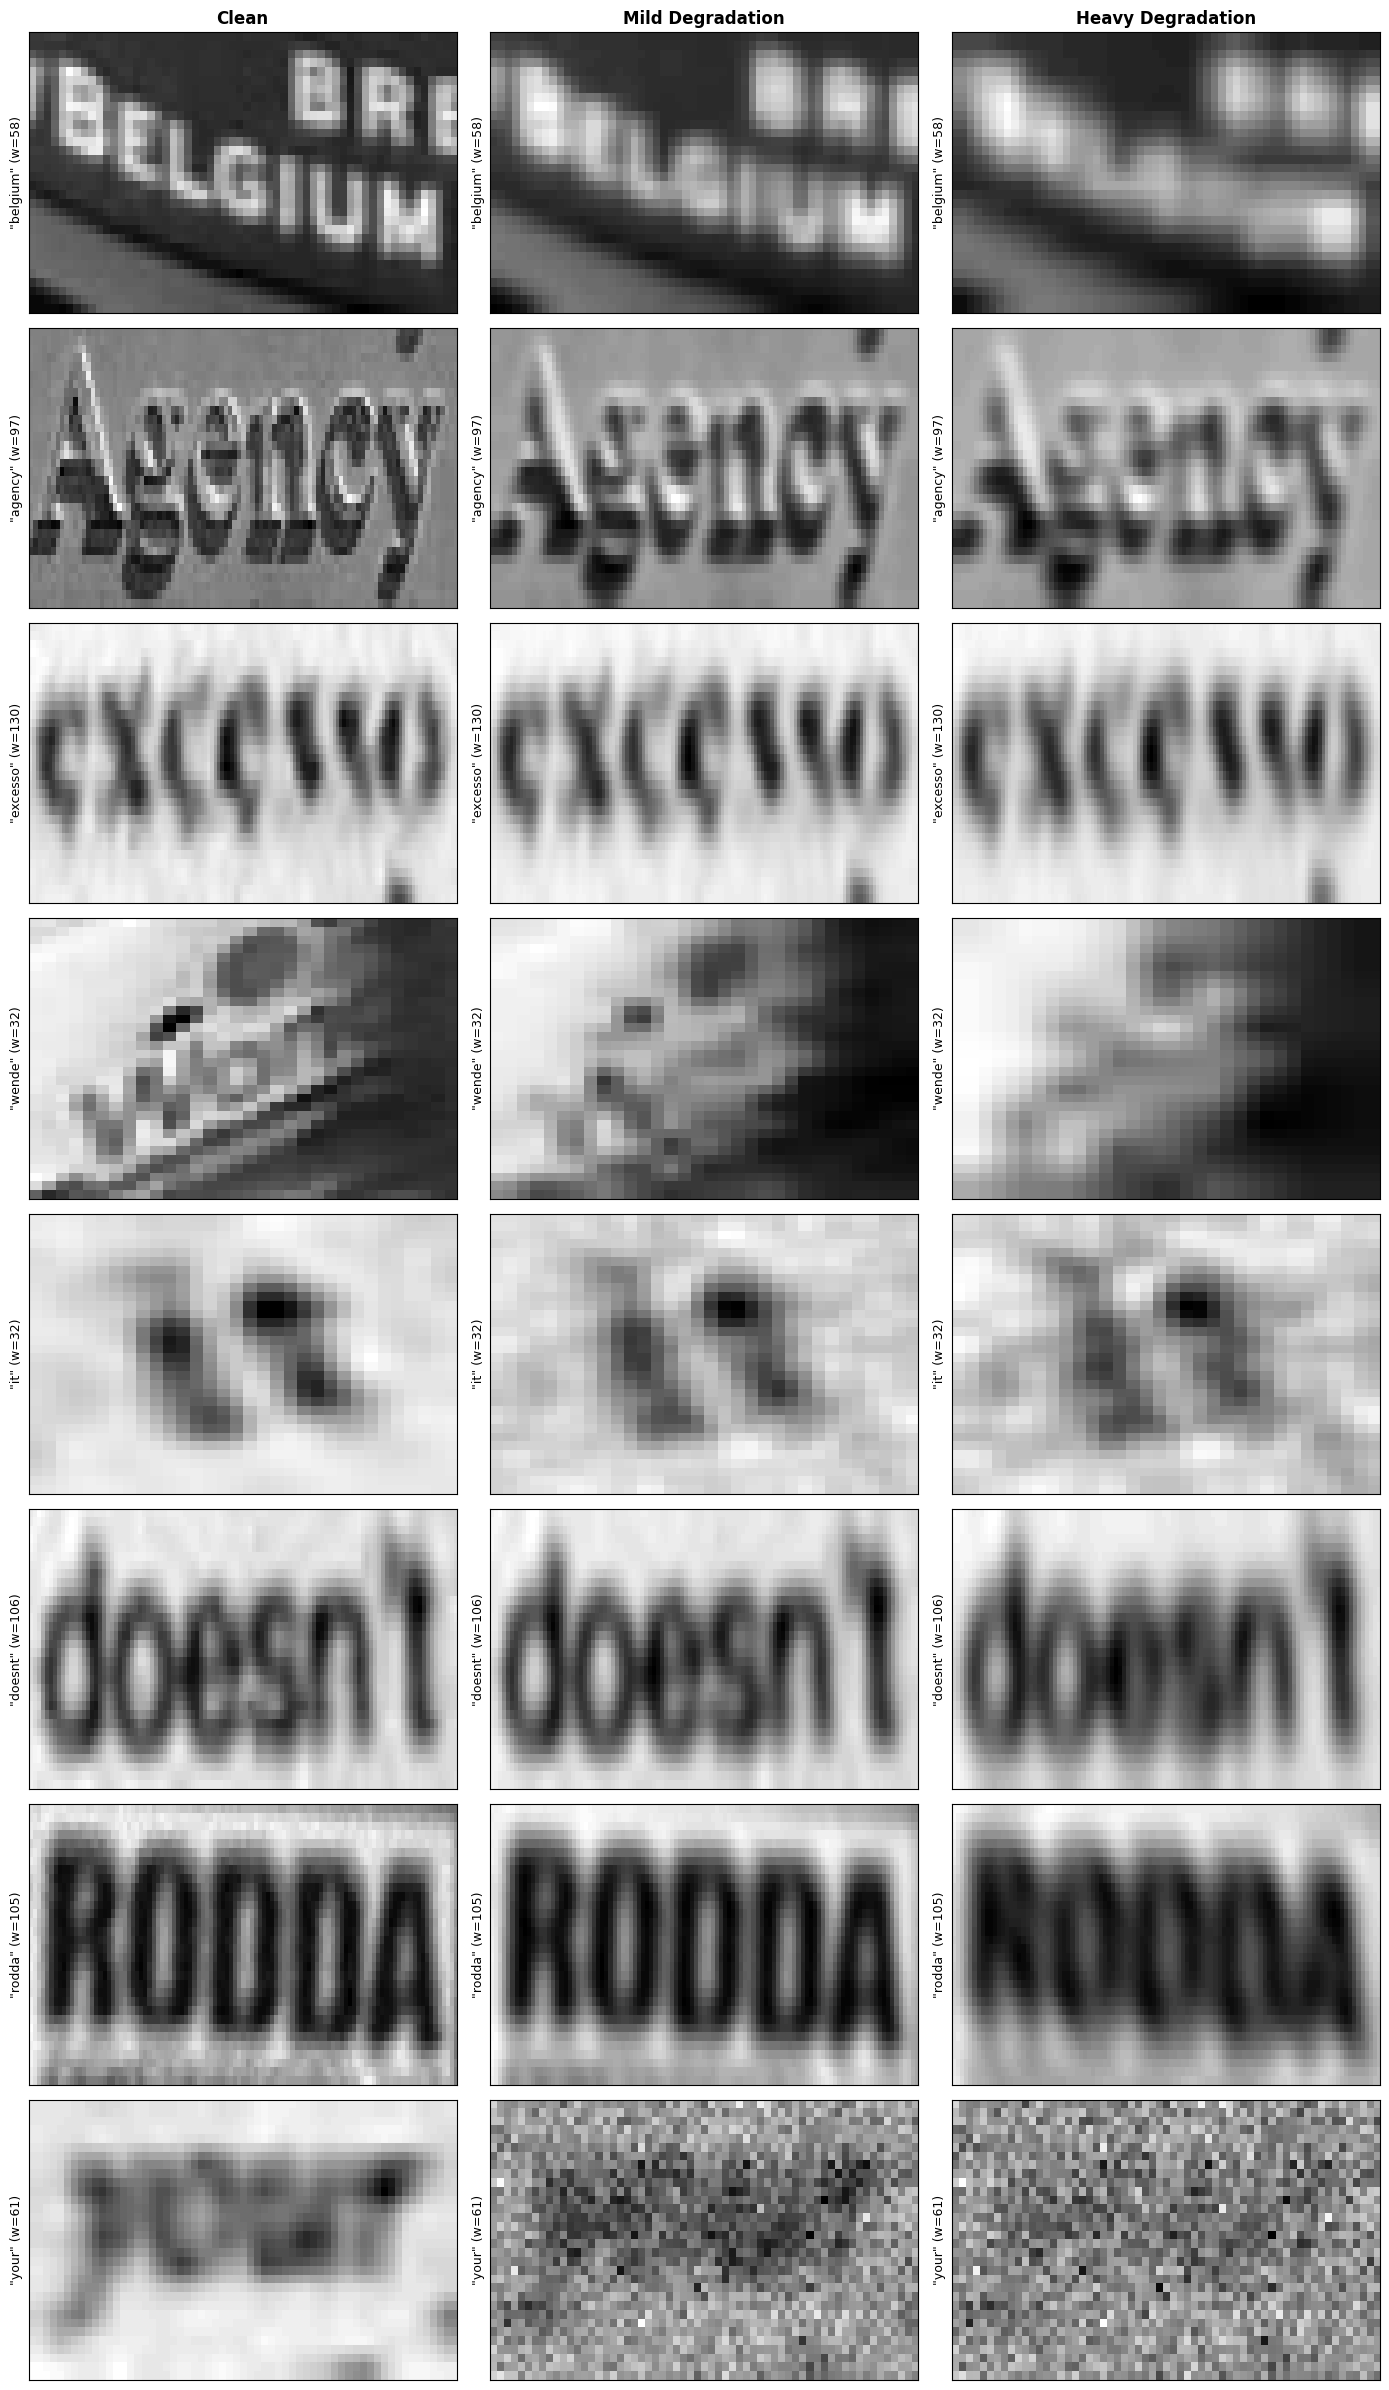

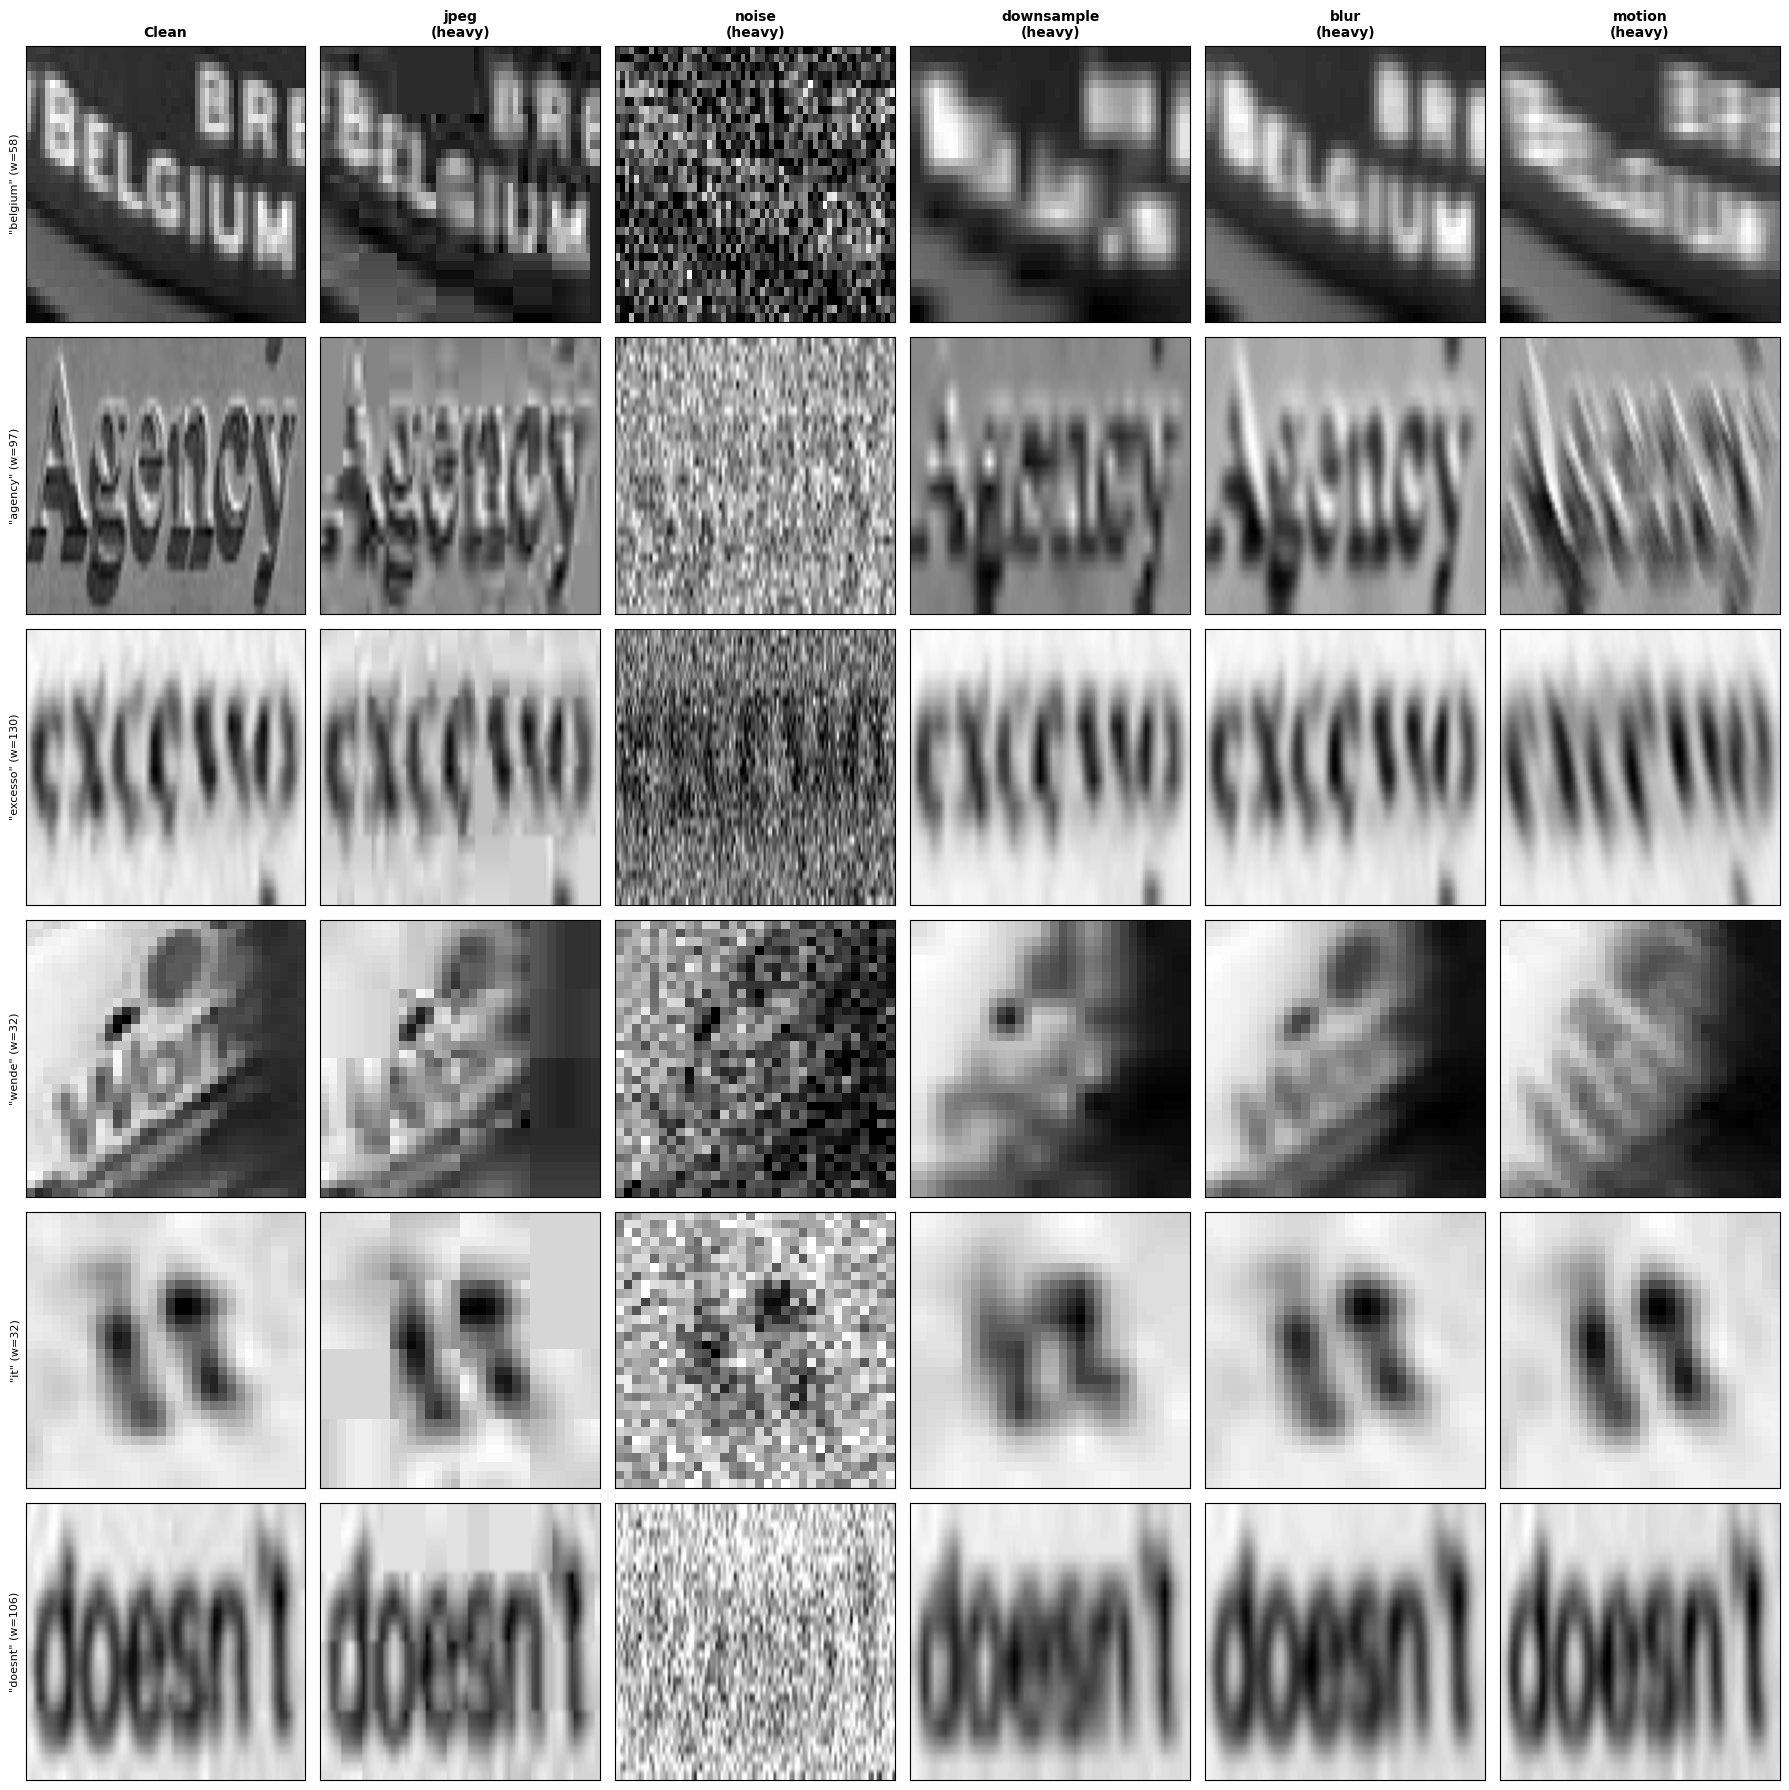

In [12]:
visualize_degradations(final_test_records, n=8)
visualize_specific_degradations(final_test_records, n=6)

In [13]:
# --- Create Datasets ---
train_ds = TotalTextDataset(final_train_records, label_encoder, cfg, augment=True)
val_ds = TotalTextDataset(final_val_records, label_encoder, cfg, augment=False)
test_ds = TotalTextDataset(final_test_records, label_encoder, cfg, augment=False)

train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True,
                          num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                          pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                        pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                         num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                         pin_memory=True)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}')

Train batches: 905, Val batches: 112, Test batches: 269


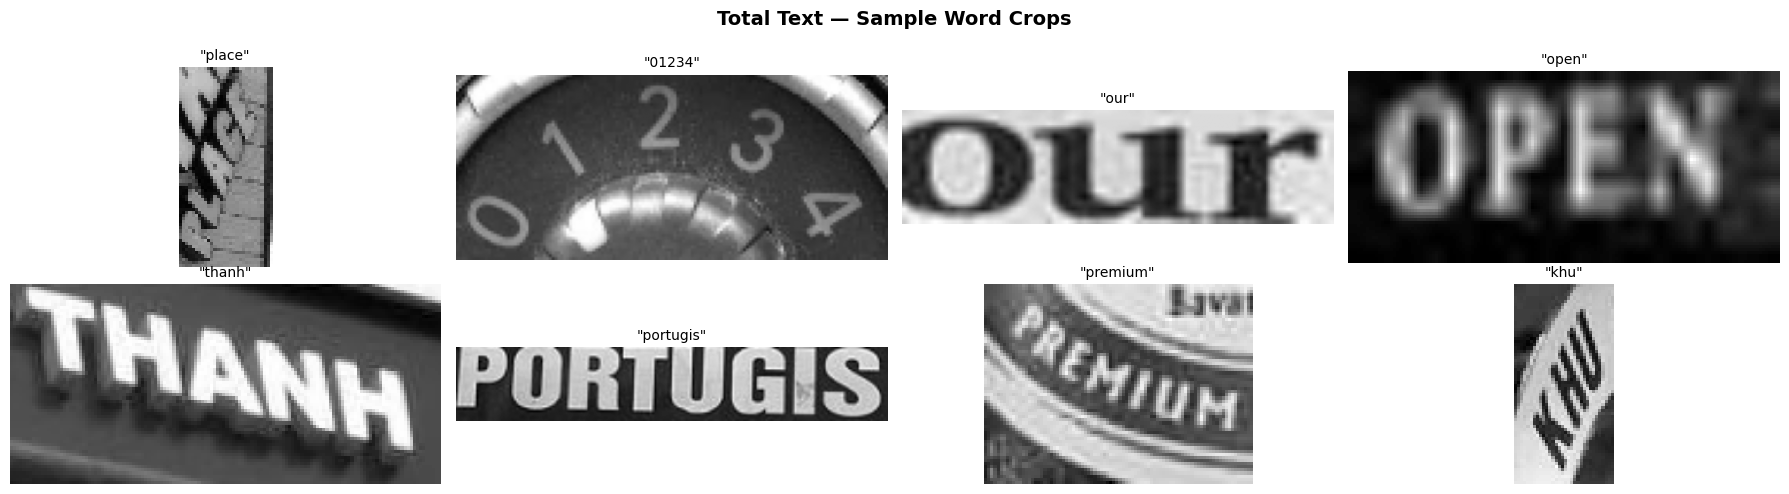

In [14]:
def show_samples(records, n=8):
    fig, axes = plt.subplots(2, n//2, figsize=(18, 5))
    axes = axes.flatten()
    sampled = random.sample(records, n)
    for i, (img_path, text, polygon) in enumerate(sampled):
        image = cv2.imread(img_path)
        if image is None:
            continue
        crop = crop_polygon_region(image, polygon, target_h=64)
        if crop is None:
            continue
        axes[i].imshow(crop, cmap='gray')
        axes[i].set_title(f'"{text}"', fontsize=10)
        axes[i].axis('off')
    plt.suptitle('Total Text — Sample Word Crops', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_records)

In [15]:
import os
import time
import gdown
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


# ---------------------------------------------------------------------------
# Model Architecture (matches Clovaai exactly)
# ---------------------------------------------------------------------------

class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, x):
        recurrent, _ = self.rnn(x)
        return self.linear(recurrent)


class ClovaaiCRNN(nn.Module):
    """
    CRNN matching Clovaai's None-VGG-BiLSTM-CTC architecture.

    Key dimensions (for 32xW grayscale input):
      CNN: 1 -> 64 -> 128 -> 256 -> 256 -> 512(BN) -> 512(BN) -> 512(BN)
      Height: 32 -> 16 -> 8 -> 8 -> 4 -> 4 -> 2 -> 1
      Width:  W -> W/2 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4 -> W/4
      So W=256 -> 64 time steps for the RNN.

    Args:
        num_classes:    alphabet size including CTC blank (index 0)
        input_channel:  1 for grayscale
        output_channel: 512 (CNN final output channels)
        hidden_size:    256 (BiLSTM hidden per direction)
    """

    def __init__(self, num_classes, input_channel=1, output_channel=512,
                 hidden_size=256):
        super().__init__()
        self.num_classes = num_classes
        self.hidden_size = hidden_size
        self.output_channel = output_channel

        # -- VGG Feature Extractor (matches Clovaai exactly) --
        # Channel progression: [64, 128, 256, 512]
        oc = [output_channel // 8, output_channel // 4,
              output_channel // 2, output_channel]  # [64, 128, 256, 512]

        self.FeatureExtraction = nn.Sequential(
            nn.Conv2d(input_channel, oc[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 64x16xW/2

            nn.Conv2d(oc[0], oc[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),                                          # -> 128x8xW/4

            nn.Conv2d(oc[1], oc[2], 3, 1, 1), nn.ReLU(True),            # -> 256x8xW/4
            nn.Conv2d(oc[2], oc[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 256x4xW/4

            nn.Conv2d(oc[2], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x4xW/4

            nn.Conv2d(oc[3], oc[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),                                # -> 512x2xW/4

            nn.Conv2d(oc[3], oc[3], 2, 1, 0, bias=False),
            nn.BatchNorm2d(oc[3]), nn.ReLU(True),                        # -> 512x1xW/4
        )

        # Collapse height
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        # -- BiLSTM Sequence Modeling --
        # Clovaai uses: BiLSTM(512->256->256) then BiLSTM(256->256->256)
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(output_channel, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )

        # -- CTC Prediction --
        # This layer gets replaced when loading pretrained weights
        self.Prediction = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        Args:
            x: (B, 1, 32, W) grayscale input
        Returns:
            log_probs: (T, B, num_classes) for CTC
        """
        # CNN: (B, 1, 32, W) -> (B, 512, 1, W/4)
        visual = self.FeatureExtraction(x)

        # Permute and pool: (B, 512, 1, W/4) -> (B, W/4, 512)
        visual = visual.permute(0, 3, 1, 2)      # (B, W/4, 512, 1)
        visual = self.AdaptiveAvgPool(visual)     # (B, W/4, 512, 1)
        visual = visual.squeeze(3)                # (B, W/4, 512)

        # BiLSTM: (B, T, 512) -> (B, T, 256)
        contextual = self.SequenceModeling(visual)

        # Prediction: (B, T, 256) -> (B, T, num_classes)
        output = self.Prediction(contextual)

        # CTC format: (T, B, num_classes)
        output = output.permute(1, 0, 2)
        log_probs = F.log_softmax(output, dim=2)
        return log_probs

In [16]:
# ---------------------------------------------------------------------------
# Weight Loading
# ---------------------------------------------------------------------------

def _extract_state_dict(ckpt):
    if isinstance(ckpt, dict) and 'state_dict' in ckpt and isinstance(ckpt['state_dict'], dict):
        ckpt = ckpt['state_dict']
    if not isinstance(ckpt, dict):
        raise ValueError('Checkpoint does not contain a state_dict-like mapping.')
    tensor_items = {k: v for k, v in ckpt.items() if torch.is_tensor(v)}
    if not tensor_items:
        raise ValueError('Checkpoint does not contain tensor parameters.')
    return tensor_items


def _load_checkpoint_state(weights_path, device='cpu'):
    ckpt = torch.load(weights_path, map_location=device, weights_only=False)
    stripped_state = {}
    for key, value in _extract_state_dict(ckpt).items():
        stripped_state[key.replace('module.', '')] = value
    return stripped_state


def _is_clova_vgg_ctc_checkpoint(weights_path, device='cpu', verbose=True):
    try:
        state = _load_checkpoint_state(weights_path, device=device)
    except Exception as exc:
        if verbose:
            print(f'Checkpoint validation failed for {weights_path}: {exc}')
        return False

    required_keys = {
        'FeatureExtraction.ConvNet.0.weight',
        'SequenceModeling.0.rnn.weight_ih_l0',
    }
    missing = [key for key in required_keys if key not in state]
    if missing:
        if verbose:
            sample_keys = list(state.keys())[:8]
            print('Checkpoint does not look like Clova None-VGG-BiLSTM-CTC.')
            print(f'Missing required keys: {missing}')
            print(f'Sample checkpoint keys: {sample_keys}')
        return False
    return True


def download_pretrained_weights(save_path='clovaai_crnn_pretrained.pth'):
    """Download the None-VGG-BiLSTM-CTC pretrained weights from Clova's Drive folder."""
    if os.path.exists(save_path) and _is_clova_vgg_ctc_checkpoint(save_path):
        print(f'Pretrained weights already exist at {save_path}')
        return save_path

    if os.path.exists(save_path):
        print(f'Existing file at {save_path} is not the Clova CRNN checkpoint. Re-downloading...')
        os.remove(save_path)

    folder_url = 'https://drive.google.com/drive/folders/15WPsuPJDCzhp2SvYZLRj8mAlT3zmoAMW'
    download_dir = 'clovaai_pretrained_models'
    print('Downloading Clovaai CRNN pretrained weights from model folder...')
    downloaded_files = gdown.download_folder(
        folder_url,
        output=download_dir,
        quiet=False,
        remaining_ok=True,
    )

    if not downloaded_files:
        raise FileNotFoundError('gdown did not return any files from the Clova pretrained-model folder.')

    exact_matches = [
        path for path in downloaded_files
        if os.path.basename(path) == 'None-VGG-BiLSTM-CTC.pth'
    ]
    candidate_matches = exact_matches or [
        path for path in downloaded_files
        if 'None-VGG-BiLSTM-CTC' in os.path.basename(path) and path.endswith('.pth')
    ]
    if not candidate_matches:
        raise FileNotFoundError(
            'Could not find None-VGG-BiLSTM-CTC weights in the downloaded Clova folder.'
        )

    selected_path = candidate_matches[0]
    if os.path.abspath(selected_path) != os.path.abspath(save_path):
        if os.path.exists(save_path):
            os.remove(save_path)
        os.replace(selected_path, save_path)

    if not _is_clova_vgg_ctc_checkpoint(save_path):
        raise ValueError(
            'Downloaded file is not the expected Clova None-VGG-BiLSTM-CTC checkpoint.'
        )

    print(f'Saved to {save_path}')
    return save_path


def load_clovaai_pretrained(model, weights_path, device='cuda'):
    """
    Load Clovaai VGG-BiLSTM-CTC pretrained weights into our model.

    The feature extractor and both BiLSTM layers should load almost completely.
    The Prediction layer is only loaded when the output shape matches.
    """
    print(f'Loading pretrained weights from {weights_path}')
    pretrained_state = _load_checkpoint_state(weights_path, device=device)

    own_state = model.state_dict()
    loaded_feature = 0
    loaded_sequence = 0
    loaded_prediction = 0
    skipped = 0
    mismatch_examples = []

    for name, param in pretrained_state.items():
        remapped = name.replace('FeatureExtraction.ConvNet.', 'FeatureExtraction.')

        if remapped not in own_state:
            skipped += 1
            continue

        if own_state[remapped].shape != param.shape:
            skipped += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f'{remapped}: pretrained={tuple(param.shape)}, ours={tuple(own_state[remapped].shape)}'
                )
            continue

        own_state[remapped].copy_(param)
        if remapped.startswith('FeatureExtraction.'):
            loaded_feature += 1
        elif remapped.startswith('SequenceModeling.'):
            loaded_sequence += 1
        elif remapped.startswith('Prediction.'):
            loaded_prediction += 1

    model.load_state_dict(own_state)

    print(
        f'Loaded feature params: {loaded_feature}, '
        f'sequence params: {loaded_sequence}, '
        f'prediction params: {loaded_prediction}, skipped: {skipped}'
    )
    if mismatch_examples:
        print('Sample mismatches:')
        for example in mismatch_examples:
            print(f'  - {example}')

    if loaded_feature == 0 or loaded_sequence == 0:
        raise ValueError(
            'Checkpoint load failed: expected VGG feature weights and BiLSTM weights were not loaded. '
            'The downloaded file is likely not the Clova None-VGG-BiLSTM-CTC model.'
        )

    if loaded_prediction == 0:
        print('Prediction layer was not loaded, which is expected when num_classes differs.')

    return model

In [17]:
# ---------------------------------------------------------------------------
# Build and Initialize
# ---------------------------------------------------------------------------

def build_pretrained_crnn(label_encoder, cfg, device=None):
    """
    Complete setup: build model, download weights, load, move to device.

    Returns model ready for fine-tuning.
    """
    device = device or cfg.DEVICE

    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    # Download and load pretrained weights
    weights_path = download_pretrained_weights()
    model = load_clovaai_pretrained(model, weights_path, device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,}")

    return model


# ---------------------------------------------------------------------------
# Training with Differential LR
# ---------------------------------------------------------------------------

def train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder):
    """
    Fine-tuning loop with differential learning rates.

    CNN (pretrained):   LR * 0.1
    BiLSTM (pretrained): LR * 0.5
    Prediction (new):    LR * 1.0
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    # Three param groups with different LRs
    cnn_params = [p for n, p in model.named_parameters()
                  if 'FeatureExtraction' in n]
    rnn_params = [p for n, p in model.named_parameters()
                  if 'SequenceModeling' in n]
    pred_params = [p for n, p in model.named_parameters()
                   if 'Prediction' in n]

    optimizer = optim.Adam([
        {'params': cnn_params,  'lr': cfg.LR * 0.1},   # gentle on pretrained CNN
        {'params': rnn_params,  'lr': cfg.LR * 0.5},   # moderate on pretrained RNN
        {'params': pred_params, 'lr': cfg.LR},          # full LR on new head
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]  # prediction head LR
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [18]:
# ---------------------------------------------------------------------------
# Training Utilities
# ---------------------------------------------------------------------------

class CTCLabelConverter:
    """Bridges between the label encoder and CTC loss input format."""

    @staticmethod
    def prepare_targets(targets, lengths):
        """
        CTC loss expects concatenated targets and a length tensor.
        Our collate_fn already produces this format, so this is a passthrough
        with validation.
        """
        assert targets.dim() == 1, "targets must be 1-D (concatenated)"
        assert lengths.sum().item() == targets.size(0), "length mismatch"
        return targets, lengths


class AverageMeter:
    """Running average tracker for loss and metrics."""

    def __init__(self):
        self.reset()

    def reset(self):
        self.sum = 0.0
        self.count = 0

    def update(self, val, n=1):
        self.sum += val * n
        self.count += n

    @property
    def avg(self):
        return self.sum / max(self.count, 1)


def greedy_decode(log_probs, label_encoder):
    """
    CTC greedy (best-path) decoding.

    Args:
        log_probs: (T, B, C) log-probabilities from the model
        label_encoder: LabelEncoder instance for index-to-char mapping

    Returns:
        list of decoded strings, one per batch element
    """
    # Argmax over classes at each time step
    _, preds = log_probs.max(2)  # (T, B)
    preds = preds.permute(1, 0)  # (B, T)

    decoded = []
    for i in range(preds.size(0)):
        raw = preds[i].cpu().tolist()
        text = label_encoder.decode(raw, remove_duplicates=True, remove_blank=True)
        decoded.append(text)
    return decoded


def compute_metrics(predictions, ground_truths):
    """
    Compute word-level accuracy and character error rate (CER).

    Args:
        predictions:    list of predicted strings
        ground_truths:  list of ground truth strings

    Returns:
        dict with 'word_acc' (exact match %) and 'cer' (character error rate %)
    """
    assert len(predictions) == len(ground_truths)

    correct = 0
    total_edit_dist = 0
    total_gt_len = 0

    for pred, gt in zip(predictions, ground_truths):
        if pred == gt:
            correct += 1
        total_edit_dist += editdistance.eval(pred, gt)
        total_gt_len += max(len(gt), 1)  # avoid division by zero

    n = max(len(predictions), 1)
    word_acc = 100.0 * correct / n
    cer = 100.0 * total_edit_dist / max(total_gt_len, 1)

    return {"word_acc": word_acc, "cer": cer}

In [19]:
# ---------------------------------------------------------------------------
# Training & Evaluation Loops
# ---------------------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer, device, label_encoder,
                    grad_clip=5.0):
    """
    Single training epoch.

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, targets, lengths in loader:
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        # Forward
        log_probs = model(images)  # (T, B, C)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        # CTC loss
        loss = criterion(log_probs, targets, input_lengths, lengths)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), B)

        # Decode for metrics (no grad needed, already detached via .data)
        with torch.no_grad():
            preds = greedy_decode(log_probs, label_encoder)

        # Reconstruct ground truth strings from concatenated targets
        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate(model, loader, criterion, device, label_encoder):
    """
    Evaluation pass (validation or test).

    Returns:
        dict with 'loss', 'word_acc', 'cer'
    """
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, targets, lengths in loader:
        images = images.to(device)
        targets = targets.to(device)
        lengths = lengths.to(device)

        log_probs = model(images)
        T, B, _ = log_probs.size()
        input_lengths = torch.full((B,), T, dtype=torch.long, device=device)

        loss = criterion(log_probs, targets, input_lengths, lengths)
        loss_meter.update(loss.item(), B)

        preds = greedy_decode(log_probs, label_encoder)

        offset = 0
        for length in lengths.cpu().tolist():
            gt_indices = targets[offset:offset + length].cpu().tolist()
            gt_text = label_encoder.decode(gt_indices,
                                           remove_duplicates=False,
                                           remove_blank=True)
            all_gts.append(gt_text)
            offset += length
        all_preds.extend(preds)

    metrics = compute_metrics(all_preds, all_gts)
    metrics["loss"] = loss_meter.avg
    return metrics

In [20]:
def train(model, train_loader, val_loader, cfg, label_encoder):
    """
    Full training loop with LR scheduling, gradient clipping, and
    best-model checkpointing based on validation word accuracy.

    Args:
        model:          CRNN instance (already on device)
        train_loader:   training DataLoader
        val_loader:     validation DataLoader
        cfg:            Config object
        label_encoder:  LabelEncoder instance

    Returns:
        history: dict of lists keyed by metric name
    """
    device = cfg.DEVICE

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [],
        "lr": [],
    }
    best_val_acc = 0.0

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    # for epoch in range(1, cfg.NUM_EPOCHS + 1):
    for epoch in range(1, 10):
        t0 = time.time()

        # -- Train --
        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        # -- Validate --
        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        # -- LR step --
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        # -- Log --
        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        # -- Checkpoint best model --
        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
                "cfg": {k: v for k, v in vars(cfg).items() if not k.startswith("_")},
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [21]:
# ---------------------------------------------------------------------------
# Inference Helpers
# ---------------------------------------------------------------------------

def load_model(checkpoint_path, label_encoder, cfg, device=None):
    """
    Load a trained ClovaaiCRNN checkpoint for inference.

    Args:
        checkpoint_path:  path to .pth file saved by training
        label_encoder:    LabelEncoder matching the training charset
        cfg:              Config object
        device:           target device (defaults to cfg.DEVICE)

    Returns:
        model on the specified device, in eval mode
    """
    device = device or cfg.DEVICE
    model = ClovaaiCRNN(
        num_classes=label_encoder.num_classes,
        input_channel=cfg.IMG_CHANNELS,
        output_channel=cfg.CNN_OUT_CHANNELS,
        hidden_size=cfg.RNN_HIDDEN_SIZE,
    ).to(device)

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    print(f"Loaded checkpoint from epoch {ckpt['epoch']} "
          f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)")
    return model


def predict_batch(model, images, label_encoder, device=None):
    """
    Run inference on a batch of preprocessed image tensors.

    Args:
        model:          ClovaaiCRNN in eval mode
        images:         (B, 1, H, W) tensor
        label_encoder:  LabelEncoder instance
        device:         target device

    Returns:
        list of predicted strings
    """
    device = device or next(model.parameters()).device
    images = images.to(device)
    with torch.no_grad():
        log_probs = model(images)
    return greedy_decode(log_probs, label_encoder)

In [22]:
print(f"Train records: {len(final_train_records)}")
print(f"Train batches: {len(train_loader)}")

Train records: 57886
Train batches: 905


In [23]:
# widths = []
# for img_path, text, polygon in final_train_records[:2000]:
#     img = cv2.imread(img_path)
#     if img is None:
#         continue
#     crop = crop_polygon_region(img, polygon, target_h=32)
#     if crop is not None:
#         widths.append(crop.shape[1])

# print(f"Width stats: min={min(widths)}, max={max(widths)}, "
#       f"mean={np.mean(widths):.0f}, median={np.median(widths):.0f}, "
#       f"95th={np.percentile(widths, 95):.0f}")

In [24]:
# ---------------------------------------------------------------------------
# Training with optional freezing for ClovaaiCRNN
# ---------------------------------------------------------------------------

def set_module_trainable(module, trainable):
    for param in module.parameters():
        param.requires_grad = trainable


def train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder):
    """
    Training loop with feature-extractor freeze/unfreeze schedule.

    Strategy:
      - Epochs 1 to freeze_cnn: feature extractor frozen, sequence/head train
      - Remaining epochs: full fine-tuning with lower LR for the feature extractor
    """
    device = cfg.DEVICE
    freeze_epochs = getattr(cfg, 'FREEZE_CNN_EPOCHS', 0)

    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)

    feat_params = [p for n, p in model.named_parameters() if n.startswith('FeatureExtraction')]
    seq_params = [p for n, p in model.named_parameters() if n.startswith('SequenceModeling')]
    pred_params = [p for n, p in model.named_parameters() if n.startswith('Prediction')]

    optimizer = optim.Adam([
        {'params': feat_params, 'lr': cfg.LR * 0.1},
        {'params': seq_params, 'lr': cfg.LR * 0.5},
        {'params': pred_params, 'lr': cfg.LR},
    ], weight_decay=cfg.WEIGHT_DECAY)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP,
                                          gamma=cfg.LR_GAMMA)

    history = {
        "train_loss": [], "train_acc": [], "train_cer": [],
        "val_loss": [], "val_acc": [], "val_cer": [], "lr": [],
    }
    best_val_acc = 0.0

    if freeze_epochs > 0:
        set_module_trainable(model.FeatureExtraction, False)

    print("=" * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | "
          f"{'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print("-" * 70)

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        t0 = time.time()

        if freeze_epochs > 0 and epoch == freeze_epochs + 1:
            set_module_trainable(model.FeatureExtraction, True)
            print(f"       ** Unfreezing feature extractor at epoch {epoch}")

        train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device,
            label_encoder, grad_clip=cfg.GRAD_CLIP
        )

        val_metrics = evaluate(model, val_loader, criterion, device, label_encoder)

        current_lr = optimizer.param_groups[2]["lr"]
        scheduler.step()

        elapsed = time.time() - t0
        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["word_acc"])
        history["train_cer"].append(train_metrics["cer"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["word_acc"])
        history["val_cer"].append(val_metrics["cer"])
        history["lr"].append(current_lr)

        print(f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
              f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
              f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
              f"{current_lr:.2e} | {elapsed:4.0f}s")

        if val_metrics["word_acc"] > best_val_acc:
            best_val_acc = val_metrics["word_acc"]
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": best_val_acc,
                "val_cer": val_metrics["cer"],
            }, cfg.SAVE_PATH)
            print(f"       ** Saved best model (val_acc={best_val_acc:.1f}%)")

    print("=" * 70)
    print(f"Training complete. Best val accuracy: {best_val_acc:.1f}%")
    return history

In [25]:
# if __name__ == "__main__":
#     # Add these to your Config:
#     # FREEZE_CNN_EPOCHS = 3    # freeze CNN for first 3 epochs
#     # LR = 1e-4               # keep the lower LR that was working

#     model = ResNetCRNN(
#         num_classes=label_encoder.num_classes,
#         rnn_hidden=cfg.RNN_HIDDEN_SIZE,
#         rnn_layers=cfg.RNN_NUM_LAYERS,
#         rnn_dropout=cfg.RNN_DROPOUT,
#         pretrained=True,
#         freeze_cnn=getattr(cfg, 'FREEZE_CNN_EPOCHS', 0),
#     ).to(cfg.DEVICE)

#     total = sum(p.numel() for p in model.parameters())
#     trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
#     print(f"Total parameters:     {total:,}")
#     print(f"Trainable parameters: {trainable:,}")
#     print(f"CNN params: {model.cnn_params:,}, RNN params: {model.rnn_params:,}")

#     history = train_with_pretrained(model, train_loader, val_loader, cfg, label_encoder)
#     # plot_training_history(history)

#     # Final test
#     criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
#     test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
#     print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
#           f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

In [47]:
if __name__ == "__main__":
    # Optional CRNN fine-tuning overrides:
    # cfg.BATCH_SIZE = 48        # lower if GPU memory is tight
    # cfg.LR = 2e-4
    # cfg.NUM_EPOCHS = 18
    # cfg.LR_STEP = 6
    # cfg.LR_GAMMA = 0.7
    # cfg.FREEZE_CNN_EPOCHS = 1
    # cfg.WEIGHT_DECAY = 5e-5

    model = build_pretrained_crnn(label_encoder, cfg)

    history = train_pretrained_crnn(model, train_loader, val_loader, cfg, label_encoder)
    # plot_training_history(history)

    # Final test
    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    test_metrics = evaluate(model, test_loader, criterion, cfg.DEVICE, label_encoder)
    print(f"\nTest -> Word Acc: {test_metrics['word_acc']:.1f}%, "
          f"CER: {test_metrics['cer']:.1f}%, Loss: {test_metrics['loss']:.4f}")

Pretrained weights already exist at clovaai_crnn_pretrained.pth
Loading pretrained weights from clovaai_crnn_pretrained.pth
Loaded feature params: 21, sequence params: 20, prediction params: 2, skipped: 1
Total parameters:     8,452,133
Trainable parameters: 8,452,133
Epoch |  TrLoss |  TrAcc |  TrCER |  VaLoss |  VaAcc |  VaCER |        LR |  Time
----------------------------------------------------------------------
    1 |  1.4981 |  40.8% |  38.6% |  0.8328 |  60.1% |  21.0% | 2.00e-04 |   30s
       ** Saved best model (val_acc=60.1%)
    2 |  1.2142 |  47.9% |  32.6% |  0.7830 |  61.9% |  19.7% | 2.00e-04 |   31s
       ** Saved best model (val_acc=61.9%)
    3 |  1.1347 |  50.5% |  30.7% |  0.7518 |  63.1% |  19.1% | 2.00e-04 |   30s
       ** Saved best model (val_acc=63.1%)
    4 |  1.0843 |  51.6% |  29.8% |  0.7362 |  63.6% |  18.7% | 2.00e-04 |   30s
       ** Saved best model (val_acc=63.6%)
    5 |  1.0443 |  52.9% |  29.0% |  0.7219 |  64.3% |  18.4% | 2.00e-04 |   31s
 

In [ ]:
degraded_test_sets = generate_all_test_sets(final_test_records)


TEST RUN FOR CRNN on NOISY SET


In [49]:
for name, records in degraded_test_sets.items():
    ds = TotalTextDataset(records, label_encoder, cfg, augment=False)
    loader = DataLoader(ds, batch_size=cfg.BATCH_SIZE, shuffle=False,
                        num_workers=cfg.NUM_WORKERS, collate_fn=collate_fn,
                        pin_memory=True)
    criterion = nn.CTCLoss(blank=cfg.BLANK_IDX, reduction="mean", zero_infinity=True)
    metrics = evaluate(model, loader, criterion, cfg.DEVICE, label_encoder)
    print(f"{name:>15} -> Word Acc: {metrics['word_acc']:.1f}%, CER: {metrics['cer']:.1f}%")

    mild_lowres -> Word Acc: 49.7%, CER: 30.0%
   heavy_lowres -> Word Acc: 13.9%, CER: 68.6%
      mild_blur -> Word Acc: 66.7%, CER: 17.4%
     heavy_blur -> Word Acc: 49.7%, CER: 31.5%


In [40]:
# ---------------------------------------------------------------------------
# TRBA dataset setup (TPS-ResNet-BiLSTM-Attn, Clovaai pretrained)
# ---------------------------------------------------------------------------

TRBA_CHARSET = '0123456789abcdefghijklmnopqrstuvwxyz'


class AttnLabelConverter:
    """Character converter for attention-based decoding with [GO] and [s] tokens."""

    def __init__(self, character):
        self.character = ['[GO]', '[s]'] + list(character)
        self.dict = {char: idx for idx, char in enumerate(self.character)}
        self.go_idx = self.dict['[GO]']
        self.eos_idx = self.dict['[s]']

    def encode(self, texts, batch_max_length=25):
        lengths = [len(text) + 1 for text in texts]  # +1 for [s]
        batch_text = torch.zeros(len(texts), batch_max_length + 2, dtype=torch.long)
        for row, text in enumerate(texts):
            tokens = list(text) + ['[s]']
            token_ids = [self.dict[token] for token in tokens]
            batch_text[row, 1:1 + len(token_ids)] = torch.tensor(token_ids, dtype=torch.long)
        return batch_text, torch.IntTensor(lengths)

    def decode(self, text_index, lengths=None):
        if isinstance(text_index, torch.Tensor):
            text_index = text_index.detach().cpu()
        texts = []
        for row in text_index:
            chars = []
            for token in row.tolist():
                char = self.character[int(token)]
                if char == '[GO]':
                    continue
                if char == '[s]':
                    break
                chars.append(char)
            texts.append(''.join(chars))
        return texts


class TRBAConfig(Config):
    IMG_WIDTH = 100
    NUM_FIDUCIAL = 20
    BATCH_MAX_LENGTH = 25
    CHARACTER = TRBA_CHARSET
    BATCH_SIZE = 64
    NUM_EPOCHS = 10
    LR = 2e-4
    LR_STEP = 8
    LR_GAMMA = 0.7
    WEIGHT_DECAY = 1e-4
    SAVE_PATH = 'trba_totaltext_best.pth'


trba_cfg = TRBAConfig()
trba_label_encoder = LabelEncoder(trba_cfg.CHARACTER)
trba_converter = AttnLabelConverter(trba_cfg.CHARACTER)


TRBA_CHARSET_SET = set(TRBA_CHARSET)


def normalize_trba_text(text):
    text = str(text).lower().strip()
    text = ''.join(ch for ch in text if ch in TRBA_CHARSET_SET)
    return text


def build_trba_records(records, max_length):
    normalized_records = []
    skipped = 0

    for img_path, text, polygon in records:
        normalized = normalize_trba_text(text)
        if not normalized or len(normalized) > max_length:
            skipped += 1
            continue
        normalized_records.append((img_path, normalized, polygon))

    print(f'Kept {len(normalized_records)} / {len(records)} records for TRBA (skipped {skipped})')
    return normalized_records


class TRBADataset(Dataset):
    """Keep-ratio resize with right padding to match Clova TRBA preprocessing."""

    def __init__(self, records, label_encoder, cfg, augment=False):
        self.records = records
        self.label_encoder = label_encoder
        self.cfg = cfg
        self.augment = augment
        self.max_width = cfg.IMG_WIDTH
        self.height = cfg.IMG_HEIGHT

        aug_list = []
        if augment:
            aug_list += [
                transforms.RandomAffine(degrees=3, shear=5),
                transforms.ColorJitter(brightness=0.3, contrast=0.3),
                transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
            ]
        self.pil_transform = transforms.Compose(aug_list) if aug_list else None
        self.to_tensor = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5]),
        ])

    def __len__(self):
        return len(self.records)

    def _resize_keep_ratio_pad(self, crop):
        h, w = crop.shape
        if h != self.height:
            new_w = max(1, int(round(w * (self.height / max(h, 1)))))
            crop = cv2.resize(crop, (new_w, self.height), interpolation=cv2.INTER_CUBIC)
            h, w = crop.shape

        target_w = min(self.max_width, max(1, int(np.ceil(self.height * (w / max(h, 1))))))
        if w != target_w:
            crop = cv2.resize(crop, (target_w, self.height), interpolation=cv2.INTER_CUBIC)

        if target_w < self.max_width:
            pad_w = self.max_width - target_w
            crop = cv2.copyMakeBorder(crop, 0, 0, 0, pad_w, cv2.BORDER_REPLICATE)

        return crop[:, :self.max_width]

    def __getitem__(self, idx):
        img_path, text, _ = self.records[idx]
        crop = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if crop is None:
            img_t = torch.zeros(1, self.height, self.max_width)
            label = self.label_encoder.encode('a')
            return img_t, label, len(label)

        if self.augment:
          # print("augmenting...")
          crop = apply_degradation_pipeline(crop, MILD_SEVERITY, ALL_DEGRADATIONS,
                                          num_degradations=2, adaptive=True)

        crop = self._resize_keep_ratio_pad(crop)

        pil_img = Image.fromarray(crop)
        if self.pil_transform:
            pil_img = self.pil_transform(pil_img)
        img_t = self.to_tensor(pil_img)
        label = self.label_encoder.encode(text)
        return img_t, label, len(label)


class AttentionCollate:
    """Reuse dataset outputs and repack targets for attention training."""

    def __init__(self, label_encoder, converter, batch_max_length):
        self.label_encoder = label_encoder
        self.converter = converter
        self.batch_max_length = batch_max_length

    def __call__(self, batch):
        images, labels, _ = zip(*batch)
        images = torch.stack(images, 0)
        texts = [
            self.label_encoder.decode(label.tolist(), remove_duplicates=False, remove_blank=True)
            for label in labels
        ]
        encoded_texts, lengths = self.converter.encode(texts, batch_max_length=self.batch_max_length)
        return images, encoded_texts, lengths, texts


trba_train_records = build_trba_records(final_train_records, trba_cfg.BATCH_MAX_LENGTH)
trba_val_records = build_trba_records(final_val_records, trba_cfg.BATCH_MAX_LENGTH)
trba_test_records = build_trba_records(final_test_records, trba_cfg.BATCH_MAX_LENGTH)

trba_train_ds = TRBADataset(trba_train_records, trba_label_encoder, trba_cfg, augment=True)
trba_val_ds = TRBADataset(trba_val_records, trba_label_encoder, trba_cfg, augment=False)
trba_test_ds = TRBADataset(trba_test_records, trba_label_encoder, trba_cfg, augment=False)

trba_collate = AttentionCollate(trba_label_encoder, trba_converter, trba_cfg.BATCH_MAX_LENGTH)

trba_train_loader = DataLoader(
    trba_train_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)
trba_val_loader = DataLoader(
    trba_val_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)
trba_test_loader = DataLoader(
    trba_test_ds,
    batch_size=trba_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=trba_cfg.NUM_WORKERS,
    collate_fn=trba_collate,
    pin_memory=True,
)

print(f'TRBA train batches: {len(trba_train_loader)}')
print(f'TRBA val batches:   {len(trba_val_loader)}')
print(f'TRBA test batches:  {len(trba_test_loader)}')

Kept 57886 / 57886 records for TRBA (skipped 0)
Kept 7152 / 7152 records for TRBA (skipped 0)
Kept 17212 / 17212 records for TRBA (skipped 0)
TRBA train batches: 905
TRBA val batches:   112
TRBA test batches:  269


In [41]:
# ---------------------------------------------------------------------------
# TRBA model architecture (matches Clovaai TPS-ResNet-BiLSTM-Attn)
# ---------------------------------------------------------------------------

import numpy as np


class TPS_SpatialTransformerNetwork(nn.Module):
    def __init__(self, F, I_size, I_r_size, I_channel_num=1):
        super().__init__()
        self.F = F
        self.I_size = I_size
        self.I_r_size = I_r_size
        self.I_channel_num = I_channel_num
        self.LocalizationNetwork = LocalizationNetwork(F, I_channel_num)
        self.GridGenerator = GridGenerator(F, I_r_size)

    def forward(self, batch_I):
        batch_C_prime = self.LocalizationNetwork(batch_I)
        build_P_prime = self.GridGenerator.build_P_prime(batch_C_prime)
        build_P_prime = build_P_prime.reshape(batch_I.size(0), self.I_r_size[0], self.I_r_size[1], 2)
        return F.grid_sample(batch_I, build_P_prime, padding_mode='border', align_corners=True)


class LocalizationNetwork(nn.Module):
    def __init__(self, F, I_channel_num):
        super().__init__()
        self.F = F
        self.I_channel_num = I_channel_num
        self.conv = nn.Sequential(
            nn.Conv2d(I_channel_num, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.AdaptiveAvgPool2d(1),
        )
        self.localization_fc1 = nn.Sequential(nn.Linear(512, 256), nn.ReLU(True))
        self.localization_fc2 = nn.Linear(256, F * 2)

        self.localization_fc2.weight.data.zero_()
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = np.linspace(0.0, -1.0, num=int(F / 2))
        ctrl_pts_y_bottom = np.linspace(1.0, 0.0, num=int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        initial_bias = np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)
        self.localization_fc2.bias.data.copy_(torch.from_numpy(initial_bias).float().view(-1))

    def forward(self, batch_I):
        batch_size = batch_I.size(0)
        features = self.conv(batch_I).view(batch_size, -1)
        return self.localization_fc2(self.localization_fc1(features)).view(batch_size, self.F, 2)


class GridGenerator(nn.Module):
    def __init__(self, F, I_r_size):
        super().__init__()
        self.eps = 1e-6
        self.I_r_height, self.I_r_width = I_r_size
        self.F = F
        self.C = self._build_C(F)
        self.P = self._build_P(self.I_r_width, self.I_r_height)
        self.register_buffer('inv_delta_C', torch.tensor(self._build_inv_delta_C(F, self.C)).float())
        self.register_buffer('P_hat', torch.tensor(self._build_P_hat(F, self.C, self.P)).float())

    def _build_C(self, F):
        ctrl_pts_x = np.linspace(-1.0, 1.0, int(F / 2))
        ctrl_pts_y_top = -1 * np.ones(int(F / 2))
        ctrl_pts_y_bottom = np.ones(int(F / 2))
        ctrl_pts_top = np.stack([ctrl_pts_x, ctrl_pts_y_top], axis=1)
        ctrl_pts_bottom = np.stack([ctrl_pts_x, ctrl_pts_y_bottom], axis=1)
        return np.concatenate([ctrl_pts_top, ctrl_pts_bottom], axis=0)

    def _build_inv_delta_C(self, F, C):
        hat_C = np.zeros((F, F), dtype=float)
        for i in range(F):
            for j in range(i, F):
                r = np.linalg.norm(C[i] - C[j])
                hat_C[i, j] = r
                hat_C[j, i] = r
        np.fill_diagonal(hat_C, 1)
        hat_C = (hat_C ** 2) * np.log(hat_C)
        delta_C = np.concatenate(
            [
                np.concatenate([np.ones((F, 1)), C, hat_C], axis=1),
                np.concatenate([np.zeros((2, 3)), C.T], axis=1),
                np.concatenate([np.zeros((1, 3)), np.ones((1, F))], axis=1),
            ],
            axis=0,
        )
        return np.linalg.inv(delta_C)

    def _build_P(self, I_r_width, I_r_height):
        I_r_grid_x = (np.arange(-I_r_width, I_r_width, 2) + 1.0) / I_r_width
        I_r_grid_y = (np.arange(-I_r_height, I_r_height, 2) + 1.0) / I_r_height
        P = np.stack(np.meshgrid(I_r_grid_x, I_r_grid_y), axis=2)
        return P.reshape([-1, 2])

    def _build_P_hat(self, F, C, P):
        n = P.shape[0]
        P_tile = np.tile(np.expand_dims(P, axis=1), (1, F, 1))
        C_tile = np.expand_dims(C, axis=0)
        P_diff = P_tile - C_tile
        rbf_norm = np.linalg.norm(P_diff, ord=2, axis=2)
        rbf = np.multiply(np.square(rbf_norm), np.log(rbf_norm + self.eps))
        return np.concatenate([np.ones((n, 1)), P, rbf], axis=1)

    def build_P_prime(self, batch_C_prime):
        batch_size = batch_C_prime.size(0)
        batch_inv_delta_C = self.inv_delta_C.unsqueeze(0).repeat(batch_size, 1, 1)
        batch_P_hat = self.P_hat.unsqueeze(0).repeat(batch_size, 1, 1)
        zeros = torch.zeros(batch_size, 3, 2, device=batch_C_prime.device, dtype=batch_C_prime.dtype)
        batch_C_prime_with_zeros = torch.cat((batch_C_prime, zeros), dim=1)
        batch_T = torch.bmm(batch_inv_delta_C, batch_C_prime_with_zeros)
        return torch.bmm(batch_P_hat, batch_T)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = self._conv3x3(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = self._conv3x3(planes, planes)
        self.bn2 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def _conv3x3(self, in_planes, out_planes, stride=1):
        return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False)

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            residual = self.downsample(x)

        out += residual
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, input_channel, output_channel, block, layers):
        super().__init__()
        self.output_channel_block = [int(output_channel / 4), int(output_channel / 2), output_channel, output_channel]
        self.inplanes = int(output_channel / 8)

        self.conv0_1 = nn.Conv2d(input_channel, int(output_channel / 16), kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_1 = nn.BatchNorm2d(int(output_channel / 16))
        self.conv0_2 = nn.Conv2d(int(output_channel / 16), self.inplanes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn0_2 = nn.BatchNorm2d(self.inplanes)
        self.relu = nn.ReLU(inplace=True)

        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer1 = self._make_layer(block, self.output_channel_block[0], layers[0])
        self.conv1 = nn.Conv2d(self.output_channel_block[0], self.output_channel_block[0], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(self.output_channel_block[0])

        self.maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.layer2 = self._make_layer(block, self.output_channel_block[1], layers[1], stride=1)
        self.conv2 = nn.Conv2d(self.output_channel_block[1], self.output_channel_block[1], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(self.output_channel_block[1])

        self.maxpool3 = nn.MaxPool2d(kernel_size=2, stride=(2, 1), padding=(0, 1))
        self.layer3 = self._make_layer(block, self.output_channel_block[2], layers[2], stride=1)
        self.conv3 = nn.Conv2d(self.output_channel_block[2], self.output_channel_block[2], kernel_size=3, stride=1, padding=1, bias=False)
        self.bn3 = nn.BatchNorm2d(self.output_channel_block[2])

        self.layer4 = self._make_layer(block, self.output_channel_block[3], layers[3], stride=1)
        self.conv4_1 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=(2, 1), padding=(0, 1), bias=False)
        self.bn4_1 = nn.BatchNorm2d(self.output_channel_block[3])
        self.conv4_2 = nn.Conv2d(self.output_channel_block[3], self.output_channel_block[3], kernel_size=2, stride=1, padding=0, bias=False)
        self.bn4_2 = nn.BatchNorm2d(self.output_channel_block[3])

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = [block(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv0_1(x)
        x = self.bn0_1(x)
        x = self.relu(x)
        x = self.conv0_2(x)
        x = self.bn0_2(x)
        x = self.relu(x)

        x = self.maxpool1(x)
        x = self.layer1(x)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.maxpool2(x)
        x = self.layer2(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.maxpool3(x)
        x = self.layer3(x)
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)

        x = self.layer4(x)
        x = self.conv4_1(x)
        x = self.bn4_1(x)
        x = self.relu(x)
        x = self.conv4_2(x)
        x = self.bn4_2(x)
        x = self.relu(x)
        return x


class ResNetFeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=512):
        super().__init__()
        self.ConvNet = ResNet(input_channel, output_channel, BasicBlock, [1, 2, 5, 3])

    def forward(self, x):
        return self.ConvNet(x)


class AttentionCell(nn.Module):
    def __init__(self, input_size, hidden_size, num_embeddings):
        super().__init__()
        self.i2h = nn.Linear(input_size, hidden_size, bias=False)
        self.h2h = nn.Linear(hidden_size, hidden_size)
        self.score = nn.Linear(hidden_size, 1, bias=False)
        self.rnn = nn.LSTMCell(input_size + num_embeddings, hidden_size)
        self.hidden_size = hidden_size

    def forward(self, prev_hidden, batch_H, char_onehots):
        batch_H_proj = self.i2h(batch_H)
        prev_hidden_proj = self.h2h(prev_hidden[0]).unsqueeze(1)
        e = self.score(torch.tanh(batch_H_proj + prev_hidden_proj))
        alpha = F.softmax(e, dim=1)
        context = torch.bmm(alpha.permute(0, 2, 1), batch_H).squeeze(1)
        concat_context = torch.cat([context, char_onehots], dim=1)
        cur_hidden = self.rnn(concat_context, prev_hidden)
        return cur_hidden, alpha


class Attention(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.attention_cell = AttentionCell(input_size, hidden_size, num_classes)
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.generator = nn.Linear(hidden_size, num_classes)

    def _char_to_onehot(self, input_char, onehot_dim):
        input_char = input_char.unsqueeze(1)
        one_hot = torch.zeros(input_char.size(0), onehot_dim, device=input_char.device)
        return one_hot.scatter_(1, input_char, 1.0)

    def forward(self, batch_H, text, is_train=True, batch_max_length=25):
        batch_size = batch_H.size(0)
        num_steps = batch_max_length + 1
        output_hiddens = torch.zeros(batch_size, num_steps, self.hidden_size, device=batch_H.device)
        hidden = (
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
            torch.zeros(batch_size, self.hidden_size, device=batch_H.device),
        )

        if is_train:
            for step in range(num_steps):
                char_onehots = self._char_to_onehot(text[:, step], onehot_dim=self.num_classes)
                hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
                output_hiddens[:, step, :] = hidden[0]
            return self.generator(output_hiddens)

        targets = torch.zeros(batch_size, dtype=torch.long, device=batch_H.device)
        probs = torch.zeros(batch_size, num_steps, self.num_classes, device=batch_H.device)
        for step in range(num_steps):
            char_onehots = self._char_to_onehot(targets, onehot_dim=self.num_classes)
            hidden, _ = self.attention_cell(hidden, batch_H, char_onehots)
            probs_step = self.generator(hidden[0])
            probs[:, step, :] = probs_step
            _, next_input = probs_step.max(dim=1)
            targets = next_input
        return probs


class ClovaaiTRBA(nn.Module):
    def __init__(self, num_class, cfg):
        super().__init__()
        self.cfg = cfg
        self.stages = {'Trans': 'TPS', 'Feat': 'ResNet', 'Seq': 'BiLSTM', 'Pred': 'Attn'}
        self.Transformation = TPS_SpatialTransformerNetwork(
            F=cfg.NUM_FIDUCIAL,
            I_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_r_size=(cfg.IMG_HEIGHT, cfg.IMG_WIDTH),
            I_channel_num=cfg.IMG_CHANNELS,
        )
        self.FeatureExtraction = ResNetFeatureExtractor(cfg.IMG_CHANNELS, cfg.CNN_OUT_CHANNELS)
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(cfg.CNN_OUT_CHANNELS, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
            BidirectionalLSTM(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE),
        )
        self.Prediction = Attention(cfg.RNN_HIDDEN_SIZE, cfg.RNN_HIDDEN_SIZE, num_class)

    def forward(self, images, text, is_train=True):
        images = self.Transformation(images)
        visual_feature = self.FeatureExtraction(images)
        visual_feature = self.AdaptiveAvgPool(visual_feature.permute(0, 3, 1, 2))
        visual_feature = visual_feature.squeeze(3)
        contextual_feature = self.SequenceModeling(visual_feature)
        return self.Prediction(
            contextual_feature.contiguous(),
            text,
            is_train=is_train,
            batch_max_length=self.cfg.BATCH_MAX_LENGTH,
        )

In [42]:
# ---------------------------------------------------------------------------
# TRBA weight loading, training, evaluation, and inference
# ---------------------------------------------------------------------------


def _is_clova_trba_checkpoint(weights_path, device='cpu', verbose=True):
    try:
        state = _load_checkpoint_state(weights_path, device=device)
    except Exception as exc:
        if verbose:
            print(f'Checkpoint validation failed for {weights_path}: {exc}')
        return False

    required_keys = {
        'Transformation.LocalizationNetwork.conv.0.weight',
        'FeatureExtraction.ConvNet.conv0_1.weight',
        'SequenceModeling.0.rnn.weight_ih_l0',
        'Prediction.attention_cell.i2h.weight',
        'Prediction.generator.weight',
    }
    missing = [key for key in required_keys if key not in state]
    if missing:
        if verbose:
            sample_keys = list(state.keys())[:12]
            print('Checkpoint does not look like Clova TPS-ResNet-BiLSTM-Attn.')
            print(f'Missing required keys: {missing}')
            print(f'Sample checkpoint keys: {sample_keys}')
        return False
    return True


def download_trba_pretrained_weights(save_path='clovaai_trba_pretrained.pth'):
    """Download Clovaai TPS-ResNet-BiLSTM-Attn weights from Google Drive."""
    if os.path.exists(save_path) and _is_clova_trba_checkpoint(save_path):
        print(f'Pretrained weights already exist at {save_path}')
        return save_path

    if os.path.exists(save_path):
        print(f'Existing file at {save_path} is not the expected Clova TRBA checkpoint. Re-downloading...')
        os.remove(save_path)

    url = 'https://drive.google.com/uc?id=1b59rXuGGmKne1AuHnkgDzoYgKeETNMv9'
    print('Downloading Clovaai TRBA pretrained weights (~200MB)...')
    gdown.download(url, save_path, quiet=False)

    if not os.path.exists(save_path):
        raise FileNotFoundError('TRBA checkpoint download did not produce a local file.')
    if not _is_clova_trba_checkpoint(save_path):
        raise ValueError('Downloaded file is not the expected Clova TPS-ResNet-BiLSTM-Attn checkpoint.')

    print(f'Saved to {save_path}')
    return save_path



def load_trba_pretrained(model, weights_path, device='cuda'):
    print(f'Loading pretrained weights from {weights_path}')
    pretrained_state = _load_checkpoint_state(weights_path, device=device)
    own_state = model.state_dict()

    loaded_transformation = 0
    loaded_feature = 0
    loaded_sequence = 0
    loaded_prediction = 0
    skipped = 0
    mismatch_examples = []

    for name, param in pretrained_state.items():
        if name not in own_state:
            skipped += 1
            continue

        if own_state[name].shape != param.shape:
            skipped += 1
            if len(mismatch_examples) < 5:
                mismatch_examples.append(
                    f'{name}: pretrained={tuple(param.shape)}, ours={tuple(own_state[name].shape)}'
                )
            continue

        own_state[name].copy_(param)
        if name.startswith('Transformation.'):
            loaded_transformation += 1
        elif name.startswith('FeatureExtraction.'):
            loaded_feature += 1
        elif name.startswith('SequenceModeling.'):
            loaded_sequence += 1
        elif name.startswith('Prediction.'):
            loaded_prediction += 1

    model.load_state_dict(own_state)

    print(
        f'Loaded transformation params: {loaded_transformation}, '
        f'feature params: {loaded_feature}, '
        f'sequence params: {loaded_sequence}, '
        f'prediction params: {loaded_prediction}, skipped: {skipped}'
    )
    if mismatch_examples:
        print('Sample mismatches:')
        for example in mismatch_examples:
            print(f'  - {example}')

    if (
        loaded_transformation == 0
        or loaded_feature == 0
        or loaded_sequence == 0
        or loaded_prediction == 0
    ):
        raise ValueError(
            'Checkpoint load failed: expected TPS, ResNet, BiLSTM, and Attention weights were not all loaded. '
            'The downloaded file is likely not the Clova TPS-ResNet-BiLSTM-Attn checkpoint.'
        )

    return model



def attn_greedy_decode(logits, converter):
    _, preds_index = logits.max(2)
    return converter.decode(preds_index)



def build_pretrained_trba(converter, cfg, device=None):
    device = device or cfg.DEVICE
    model = ClovaaiTRBA(num_class=len(converter.character), cfg=cfg).to(device)
    weights_path = download_trba_pretrained_weights()
    model = load_trba_pretrained(model, weights_path, device=device)

    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total parameters:     {total:,}')
    print(f'Trainable parameters: {trainable:,}')
    return model



def train_one_epoch_attn(model, loader, criterion, optimizer, device, converter, cfg, grad_clip=5.0):
    model.train()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, encoded_texts, _, texts in loader:
        images = images.to(device)
        encoded_texts = encoded_texts.to(device)

        preds = model(images, encoded_texts[:, :-1], is_train=True)
        target = encoded_texts[:, 1:]
        loss = criterion(preds.contiguous().view(-1, preds.size(-1)), target.contiguous().view(-1))

        optimizer.zero_grad()
        loss.backward()
        if grad_clip > 0:
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        loss_meter.update(loss.item(), images.size(0))

        with torch.no_grad():
            text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
            pred_texts = attn_greedy_decode(model(images, text_for_pred, is_train=False), converter)

        all_preds.extend(pred_texts)
        all_gts.extend(texts)

    metrics = compute_metrics(all_preds, all_gts)
    metrics['loss'] = loss_meter.avg
    return metrics


@torch.no_grad()
def evaluate_attn(model, loader, criterion, device, converter, cfg):
    model.eval()
    loss_meter = AverageMeter()
    all_preds = []
    all_gts = []

    for images, encoded_texts, _, texts in loader:
        images = images.to(device)
        encoded_texts = encoded_texts.to(device)

        preds = model(images, encoded_texts[:, :-1], is_train=True)
        target = encoded_texts[:, 1:]
        loss = criterion(preds.contiguous().view(-1, preds.size(-1)), target.contiguous().view(-1))
        loss_meter.update(loss.item(), images.size(0))

        text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
        pred_texts = attn_greedy_decode(model(images, text_for_pred, is_train=False), converter)

        all_preds.extend(pred_texts)
        all_gts.extend(texts)

    metrics = compute_metrics(all_preds, all_gts)
    metrics['loss'] = loss_meter.avg
    return metrics



def train_pretrained_trba(model, train_loader, val_loader, cfg, converter):
    device = cfg.DEVICE
    criterion = nn.CrossEntropyLoss(ignore_index=converter.go_idx)

    tps_params = [p for n, p in model.named_parameters() if n.startswith('Transformation')]
    feat_params = [p for n, p in model.named_parameters() if n.startswith('FeatureExtraction')]
    seq_params = [p for n, p in model.named_parameters() if n.startswith('SequenceModeling')]
    pred_params = [p for n, p in model.named_parameters() if n.startswith('Prediction')]

    optimizer = optim.Adam(
        [
            {'params': tps_params, 'lr': cfg.LR * 0.05},
            {'params': feat_params, 'lr': cfg.LR * 0.10},
            {'params': seq_params, 'lr': cfg.LR * 0.25},
            {'params': pred_params, 'lr': cfg.LR * 0.50},
        ],
        weight_decay=cfg.WEIGHT_DECAY,
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=cfg.LR_STEP, gamma=cfg.LR_GAMMA)

    history = {
        'train_loss': [], 'train_acc': [], 'train_cer': [],
        'val_loss': [], 'val_acc': [], 'val_cer': [], 'lr': [],
    }
    best_val_acc = 0.0

    print('=' * 70)
    print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrAcc':>6} | {'TrCER':>6} | {'VaLoss':>7} | {'VaAcc':>6} | {'VaCER':>6} | {'LR':>9} | {'Time':>5}")
    print('-' * 70)

    # for epoch in range(1, cfg.NUM_EPOCHS + 1):
    for epoch in range(1, 10):
        t0 = time.time()
        train_metrics = train_one_epoch_attn(
            model, train_loader, criterion, optimizer, device, converter, cfg, grad_clip=cfg.GRAD_CLIP
        )
        val_metrics = evaluate_attn(model, val_loader, criterion, device, converter, cfg)

        current_lr = optimizer.param_groups[-1]['lr']
        scheduler.step()

        elapsed = time.time() - t0
        history['train_loss'].append(train_metrics['loss'])
        history['train_acc'].append(train_metrics['word_acc'])
        history['train_cer'].append(train_metrics['cer'])
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['word_acc'])
        history['val_cer'].append(val_metrics['cer'])
        history['lr'].append(current_lr)

        print(
            f"{epoch:5d} | {train_metrics['loss']:7.4f} | {train_metrics['word_acc']:5.1f}% | "
            f"{train_metrics['cer']:5.1f}% | {val_metrics['loss']:7.4f} | "
            f"{val_metrics['word_acc']:5.1f}% | {val_metrics['cer']:5.1f}% | "
            f"{current_lr:.2e} | {elapsed:4.0f}s"
        )

        if val_metrics['word_acc'] > best_val_acc:
            best_val_acc = val_metrics['word_acc']
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_acc': best_val_acc,
                    'val_cer': val_metrics['cer'],
                    'character': cfg.CHARACTER,
                },
                cfg.SAVE_PATH,
            )
            print(f'       ** Saved best model (val_acc={best_val_acc:.1f}%)')

    print('=' * 70)
    print(f'Training complete. Best val accuracy: {best_val_acc:.1f}%')
    return history



def load_trba_model(checkpoint_path, converter, cfg, device=None):
    device = device or cfg.DEVICE
    model = ClovaaiTRBA(num_class=len(converter.character), cfg=cfg).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(
        f"Loaded checkpoint from epoch {ckpt['epoch']} "
        f"(val_acc={ckpt['val_acc']:.1f}%, val_cer={ckpt['val_cer']:.1f}%)"
    )
    return model



def predict_batch_attn(model, images, converter, cfg, device=None):
    device = device or next(model.parameters()).device
    images = images.to(device)
    text_for_pred = torch.zeros(images.size(0), cfg.BATCH_MAX_LENGTH + 1, dtype=torch.long, device=device)
    with torch.no_grad():
        preds = model(images, text_for_pred, is_train=False)
    return attn_greedy_decode(preds, converter)

In [43]:

if __name__ == '__main__':
    # Optional TRBA fine-tuning overrides:
    # trba_cfg.BATCH_SIZE = 16   # lower if GPU memory is tight
    # trba_cfg.LR = 2e-4
    # trba_cfg.NUM_EPOCHS = 20
    # trba_cfg.LR_STEP = 8
    # trba_cfg.LR_GAMMA = 0.7
    # trba_cfg.WEIGHT_DECAY = 1e-4

    trba_model = build_pretrained_trba(trba_converter, trba_cfg)

    trba_history = train_pretrained_trba(
        trba_model,
        trba_train_loader,
        trba_val_loader,
        trba_cfg,
        trba_converter,
    )
    # plot_training_history(trba_history)

    trba_criterion = nn.CrossEntropyLoss(ignore_index=trba_converter.go_idx)
    trba_test_metrics = evaluate_attn(
        trba_model,
        trba_test_loader,
        trba_criterion,
        trba_cfg.DEVICE,
        trba_converter,
        trba_cfg,
    )
    print(
        f"\nTRBA Test -> Word Acc: {trba_test_metrics['word_acc']:.1f}%, "
        f"CER: {trba_test_metrics['cer']:.1f}%, Loss: {trba_test_metrics['loss']:.4f}"
    )

Pretrained weights already exist at clovaai_trba_pretrained.pth
Loading pretrained weights from clovaai_trba_pretrained.pth
Loaded transformation params: 30, feature params: 192, sequence params: 20, prediction params: 10, skipped: 0
Total parameters:     49,555,182
Trainable parameters: 49,555,182
Epoch |  TrLoss |  TrAcc |  TrCER |  VaLoss |  VaAcc |  VaCER |        LR |  Time
----------------------------------------------------------------------
    1 |  0.7855 |  55.8% |  29.3% |  0.4589 |  69.7% |  16.8% | 1.00e-04 |  104s
       ** Saved best model (val_acc=69.7%)
    2 |  0.6547 |  61.0% |  25.4% |  0.4278 |  71.3% |  15.7% | 1.00e-04 |  104s
       ** Saved best model (val_acc=71.3%)
    3 |  0.6004 |  63.2% |  23.6% |  0.4146 |  71.4% |  15.2% | 1.00e-04 |  104s
       ** Saved best model (val_acc=71.4%)
    4 |  0.5591 |  65.3% |  22.2% |  0.4057 |  72.0% |  14.7% | 1.00e-04 |  105s
       ** Saved best model (val_acc=72.0%)
    5 |  0.5357 |  66.4% |  21.6% |  0.3961 |  72.5

In [44]:
degraded_test_sets = generate_all_test_sets(final_test_records)


Degrading -> data/degraded_test/mild_lowres: 100%|██████████| 17212/17212 [00:07<00:00, 2222.00it/s]


Saved 17212 degraded crops to data/degraded_test/mild_lowres


Degrading -> data/degraded_test/heavy_lowres: 100%|██████████| 17212/17212 [00:07<00:00, 2266.06it/s]


Saved 17212 degraded crops to data/degraded_test/heavy_lowres


Degrading -> data/degraded_test/mild_blur: 100%|██████████| 17212/17212 [00:06<00:00, 2752.88it/s]


Saved 17212 degraded crops to data/degraded_test/mild_blur


Degrading -> data/degraded_test/heavy_blur: 100%|██████████| 17212/17212 [00:07<00:00, 2372.64it/s]

Saved 17212 degraded crops to data/degraded_test/heavy_blur


TEST RUN FOR TRBA ON NOISY TEST SET

In [46]:
trba_criterion = nn.CrossEntropyLoss(ignore_index=trba_converter.go_idx)

for name, records in degraded_test_sets.items():
    trba_records = build_trba_records(records, trba_cfg.BATCH_MAX_LENGTH)
    ds = TRBADataset(trba_records, trba_label_encoder, trba_cfg, augment=False)
    loader = DataLoader(ds, batch_size=trba_cfg.BATCH_SIZE, shuffle=False,
                        num_workers=trba_cfg.NUM_WORKERS,
                        collate_fn=trba_collate, pin_memory=True)
    metrics = evaluate_attn(trba_model, loader, trba_criterion,
                            trba_cfg.DEVICE, trba_converter, trba_cfg)
    print(f"{name:>15} -> Word Acc: {metrics['word_acc']:.1f}%, CER: {metrics['cer']:.1f}%")

Kept 17212 / 17212 records for TRBA (skipped 0)
    mild_lowres -> Word Acc: 57.9%, CER: 26.4%
Kept 17212 / 17212 records for TRBA (skipped 0)
   heavy_lowres -> Word Acc: 18.3%, CER: 68.2%
Kept 17212 / 17212 records for TRBA (skipped 0)
      mild_blur -> Word Acc: 73.5%, CER: 14.0%
Kept 17212 / 17212 records for TRBA (skipped 0)
     heavy_blur -> Word Acc: 60.2%, CER: 25.2%
